In [1]:
import pymc as pm; import arviz as az; import sys; import numpy as np; import pickle
import nutpie; import pytensor.tensor as pt; import matplotlib.pyplot as plt
sys.path.append(r'C:\Users\awast\OneDrive\Desktop\MKM')
from _CO_Oxidation.common import kb_eV, T, kb_J, h, F, N_A
from _CO_Oxidation import wrapper_base as wp
from _CO_Oxidation.wrapper_base import plot_posteriors, plot_model_fits, plot_coverages, plot_drc

C_KOH_list = np.array([0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
experiments_data = pickle.load(open('import_Ag75Pd25_base_replicates.pkl', 'rb'))
wp.process_experimental_data(experiments_data, C_KOH_list, P_CO_list)
E_in = wp.E_in; P_CO_in = wp.P_CO_in; C_KOH_in = wp.C_KOH_in

def fit_and_evaluate(model, draws=1000, tune=2000, chains=4, cores=4, init_mean=None, target_accept=0.9):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = az.loo(trace, pointwise=True)
    print(loo); az.plot_khat(loo); plt.title("Pareto k diagnostic"); plt.show()
    trace = wp.add_post_sampling_observables(trace)
    return trace, loo

def observables(log_rate):
    pm.Deterministic('log_rate', log_rate)
    rate_model = pt.exp(log_rate)
    sigma_rel = pm.Gamma('sigma_rel', alpha=2, beta=20)
    sigma_base = pm.HalfNormal('sigma_base', sigma=1e-2)
    exponent =  pm.HalfNormal('exponent', sigma=1)
    sigma_model = pt.sqrt(sigma_base**2 + (sigma_rel**2)*(rate_model ** exponent))
    # sigma_total = pt.sqrt(wp.rate_SD_obs**2 + sigma_model**2)
    rate = pm.StudentT('rate', nu=4, mu=rate_model, sigma=sigma_model, observed=wp.rate_obs_matrix)
    return rate

Ag_comp = 0.75

# LH 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.35,31
,3000,0,0.34,23
,3000,0,0.33,31
,3000,0,0.36,23


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1330.78    53.98
p_loo        5.06        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



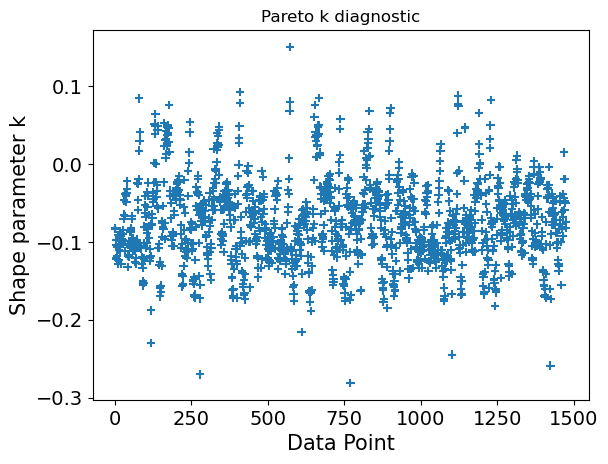

In [2]:
with pm.Model() as LH:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* -> COOH* + * (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH_Pd + np.log(1-Ag_comp)
    rate = observables(log_rate) 

trace_LH, loo_LH = fit_and_evaluate(LH)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0   0.008  0.007  -0.005    0.020      0.000    0.000     754.0     655.0   1.01
deltaG4_0   0.033  0.003   0.027    0.039      0.000    0.000    1149.0    1899.0   1.01
Gact2_0     0.593  0.004   0.585    0.600      0.000    0.000     908.0     632.0   1.01
sigma_rel   1.957  0.086   1.790    2.114      0.002    0.001    1533.0    2095.0   1.00
sigma_base  0.004  0.003   0.000    0.010      0.000    0.000    2016.0    1221.0   1.00
exponent    0.595  0.014   0.569    0.622      0.000    0.000    1844.0    2342.0   1.00


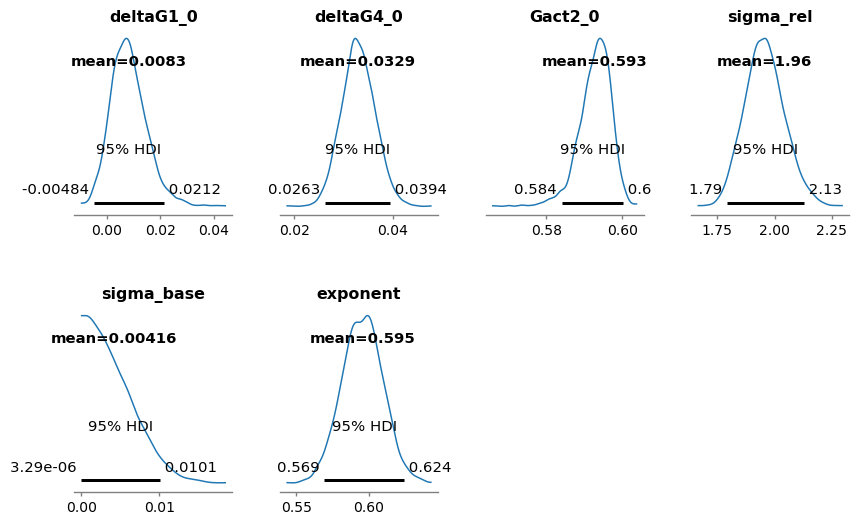

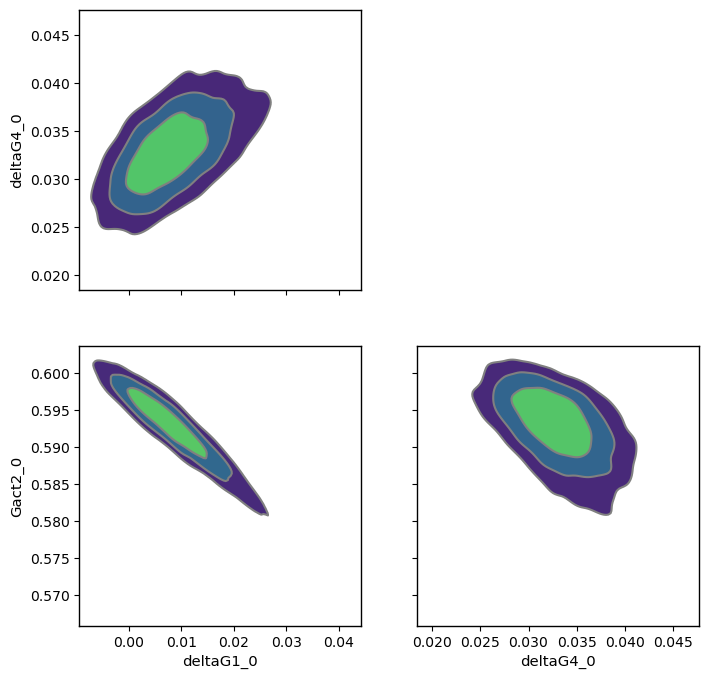

Sampling: [rate]


rate: 0.571


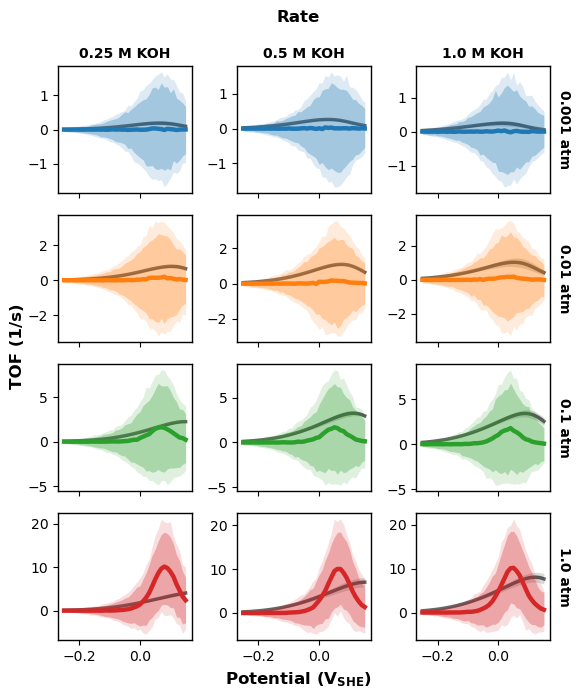

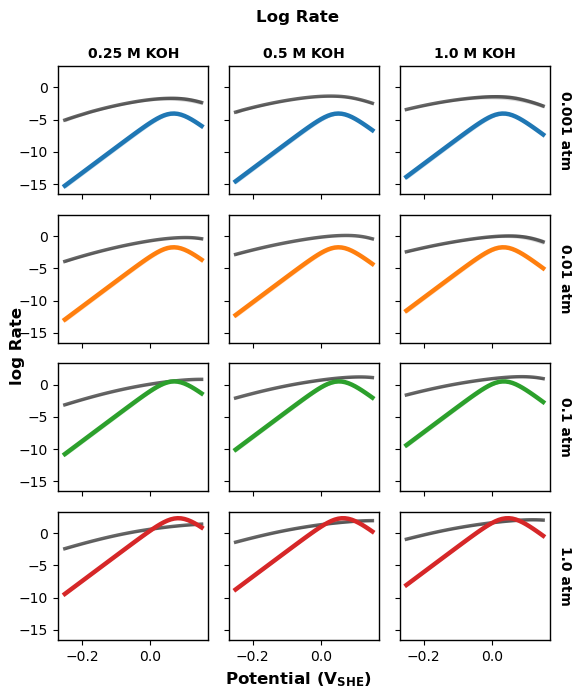

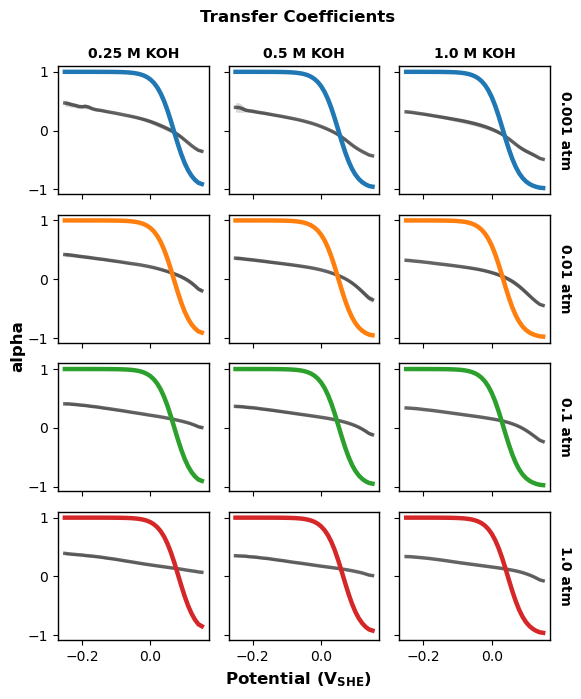

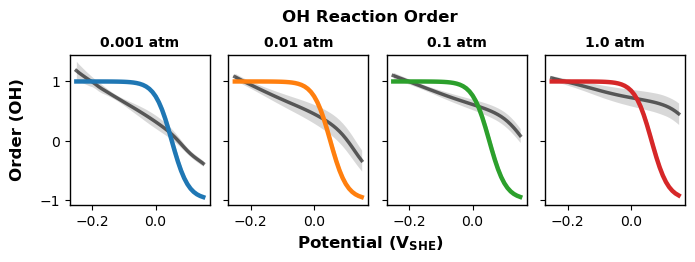

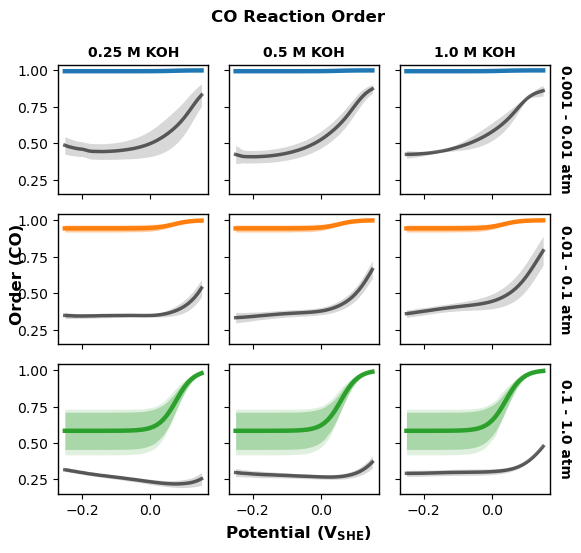

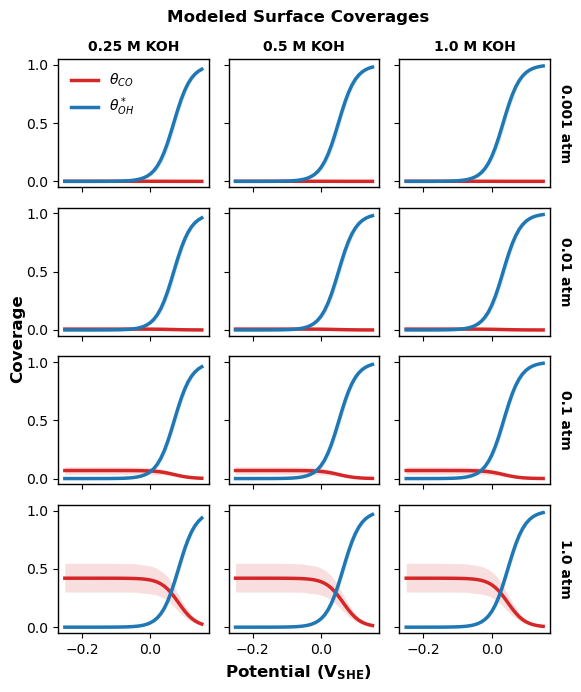

In [3]:
ppc_LH = plot_posteriors(trace_LH, LH)
plot_model_fits(trace_LH, ppc_LH); plot_coverages(trace_LH)

# BF

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.40,15
,3000,0,0.45,15
,3000,0,0.09,47
,3000,0,0.41,7


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -808.42    60.06
p_loo      339.51        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



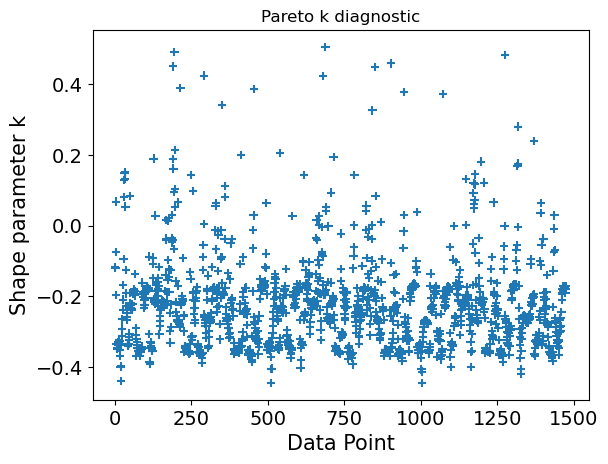

In [4]:
with pm.Model() as BF:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH# -> COOH* + # (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2 = Gact2_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    rate = observables(log_rate) 

trace_BF, loo_BF = fit_and_evaluate(BF)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.079  0.033  -0.102   -0.016      0.016    0.010       7.0      32.0   1.53
deltaG4_0   0.084  0.105  -0.104    0.156      0.052    0.030       7.0      32.0   1.53
deltaG5_0  -0.054  0.196  -0.174    0.315      0.097    0.057       7.0      33.0   1.54
Gact2_0     0.616  0.167   0.298    0.713      0.082    0.049       7.0      33.0   1.54
sigma_rel   0.708  0.408   0.440    1.453      0.203    0.117       7.0      31.0   1.53
sigma_base  0.019  0.009   0.000    0.028      0.004    0.002       7.0      28.0   1.53
exponent    1.694  0.566   0.690    2.137      0.280    0.159       7.0      29.0   1.53


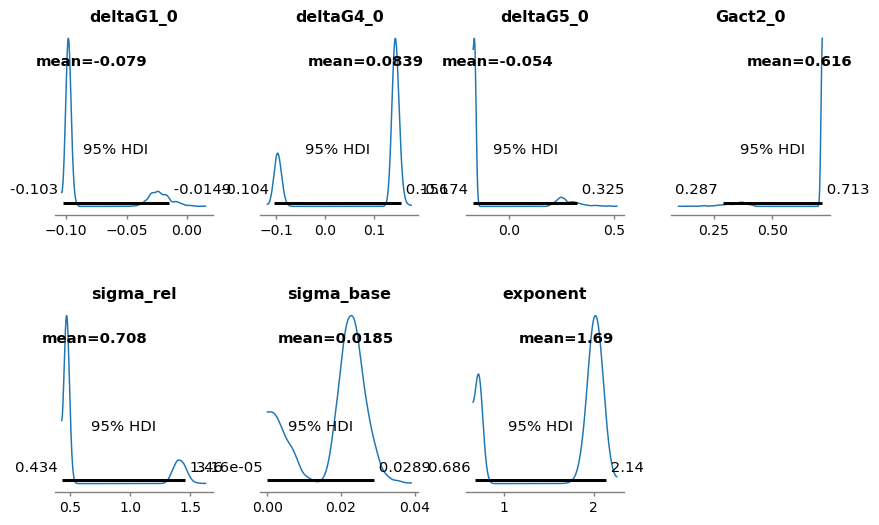

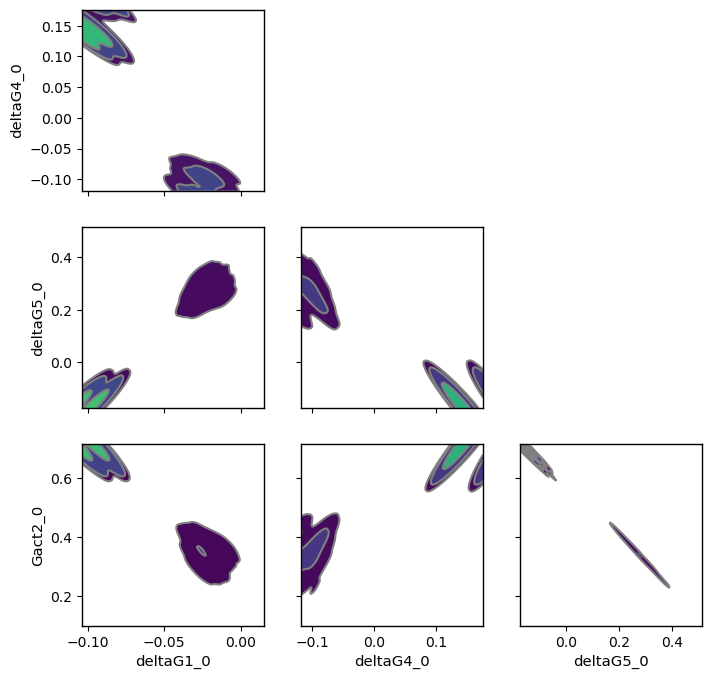

Sampling: [rate]


rate: 0.520


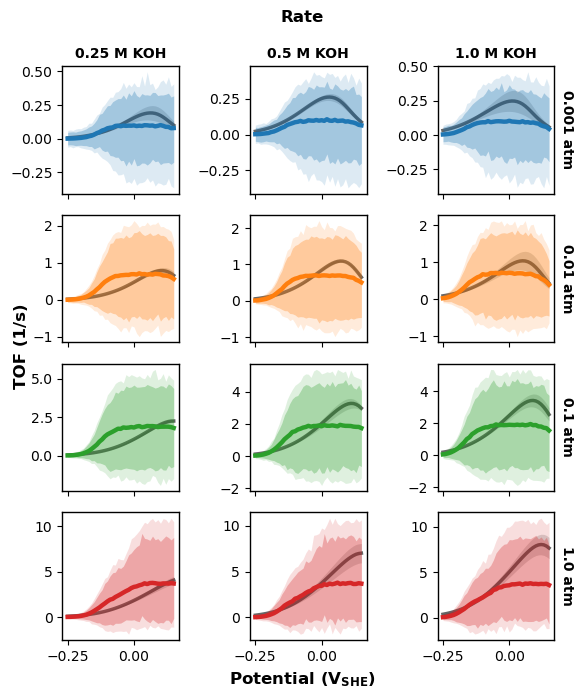

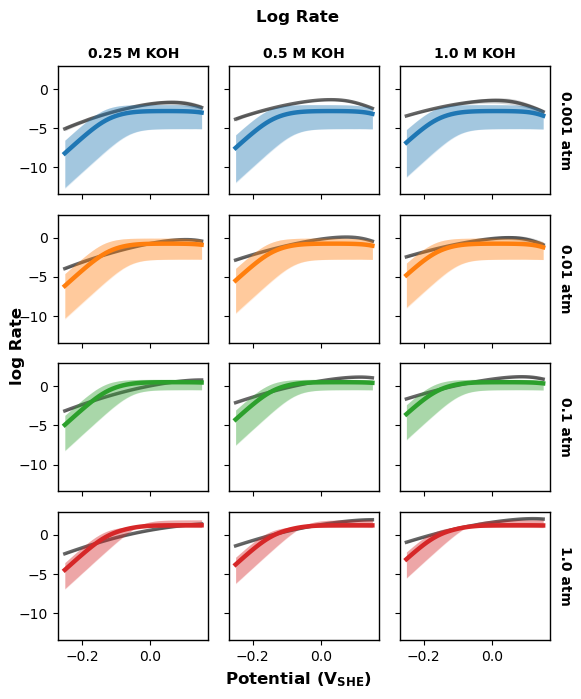

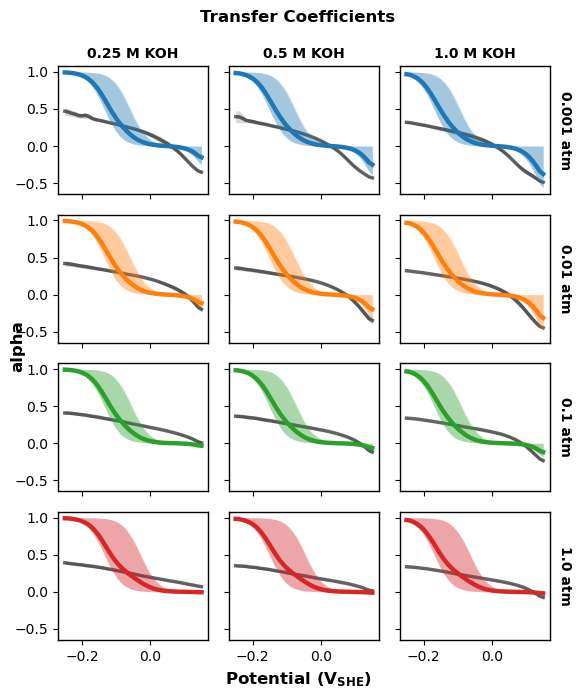

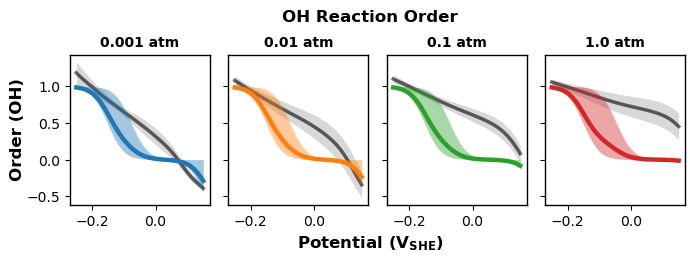

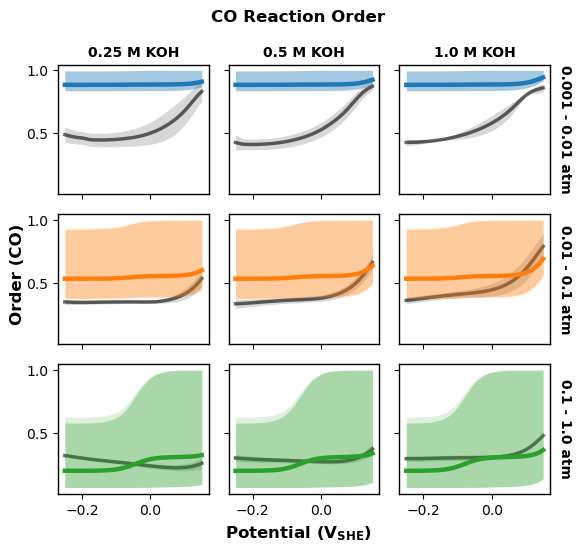

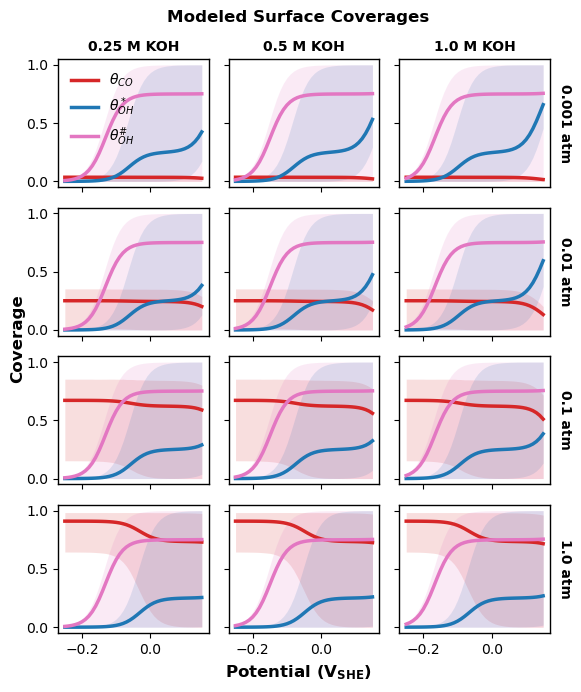

In [5]:
ppc_BF = plot_posteriors(trace_BF, BF)
plot_model_fits(trace_BF, ppc_BF); plot_coverages(trace_BF)

# ER

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,1,0.43,15
,3000,0,0.44,7
,3000,1,0.48,15
,3000,1,0.45,7


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   141.27    57.82
p_loo       68.86        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



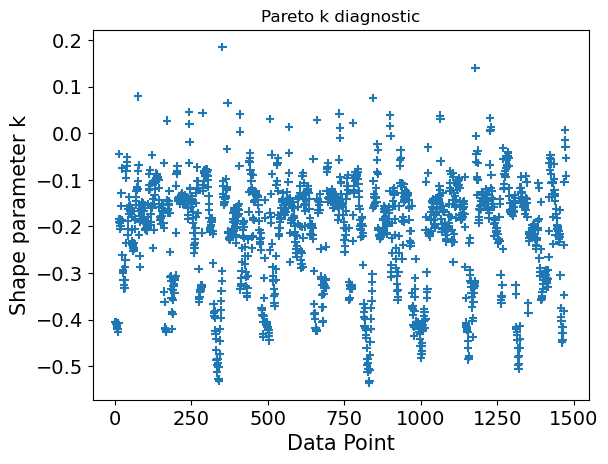

In [6]:
with pm.Model() as ER:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + np.log(C_KOH_in)
    rate = observables(log_rate) 

trace_ER, loo_ER = fit_and_evaluate(ER)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.110  0.005  -0.115   -0.099      0.003    0.001       7.0      35.0   1.53
deltaG4_0   0.059  0.005   0.053    0.069      0.002    0.001       7.0      30.0   1.53
Gact2_0     0.705  0.001   0.702    0.706      0.001    0.000       7.0      36.0   1.53
beta_2      0.245  0.003   0.239    0.251      0.000    0.000     102.0    2875.0   1.03
sigma_rel   0.312  0.032   0.247    0.346      0.015    0.008       7.0      30.0   1.53
sigma_base  0.012  0.017   0.000    0.043      0.009    0.005       7.0      32.0   1.53
exponent    1.848  0.186   1.654    2.223      0.089    0.051       7.0      29.0   1.53


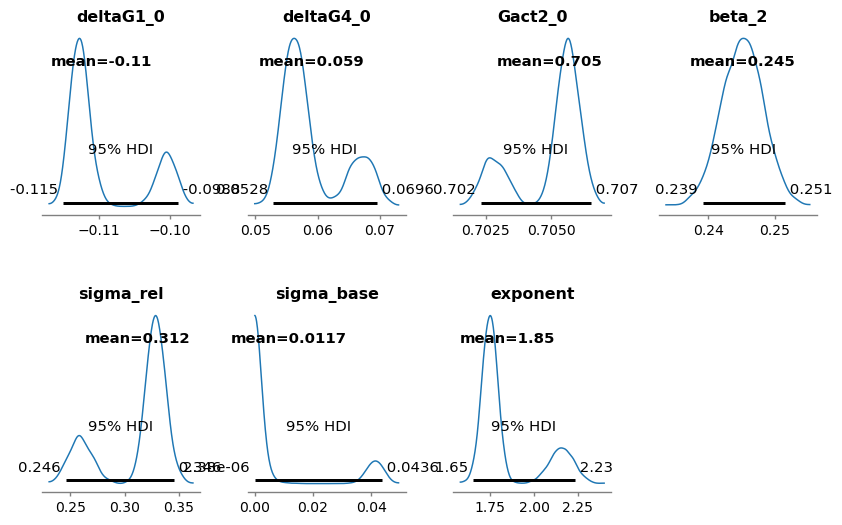

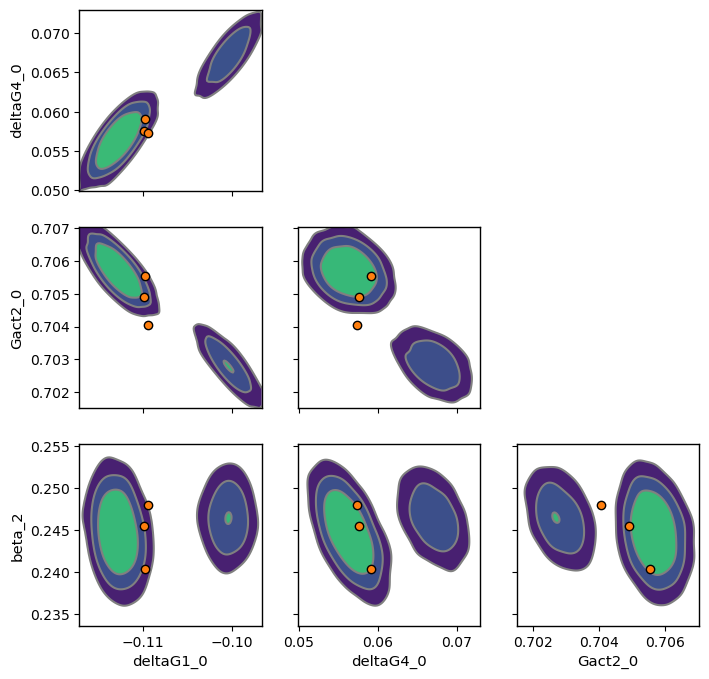

Sampling: [rate]


rate: 0.765


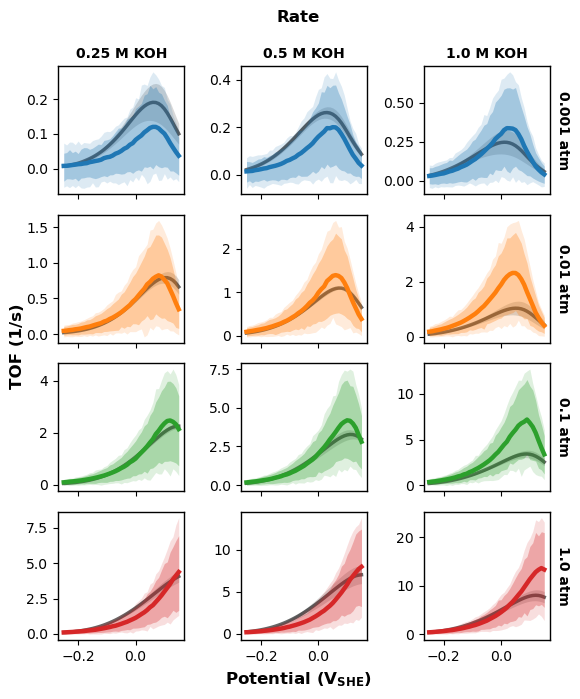

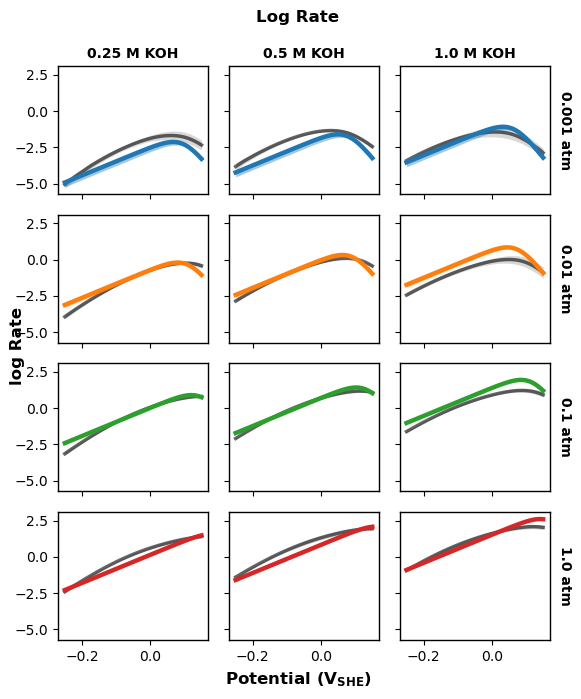

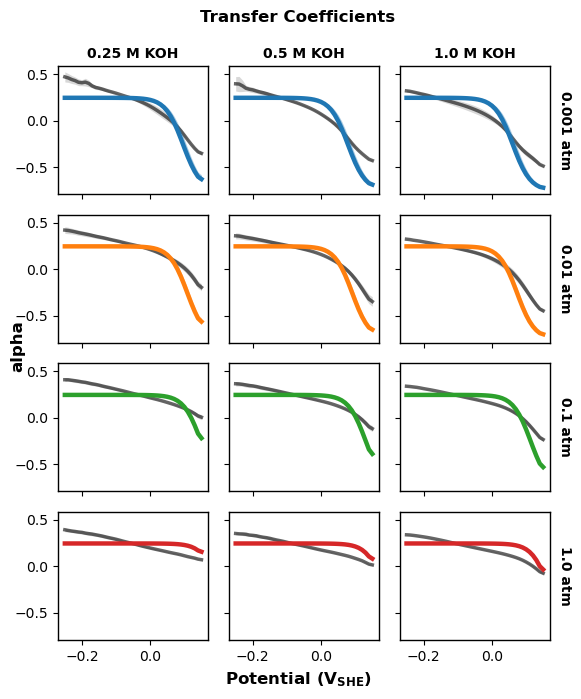

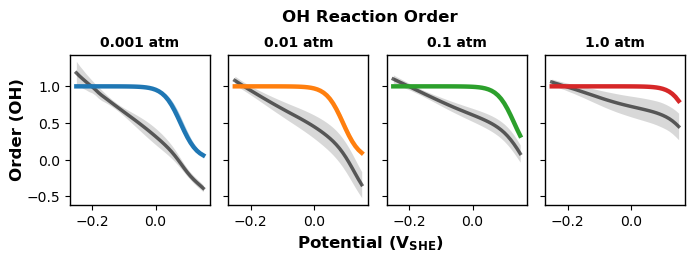

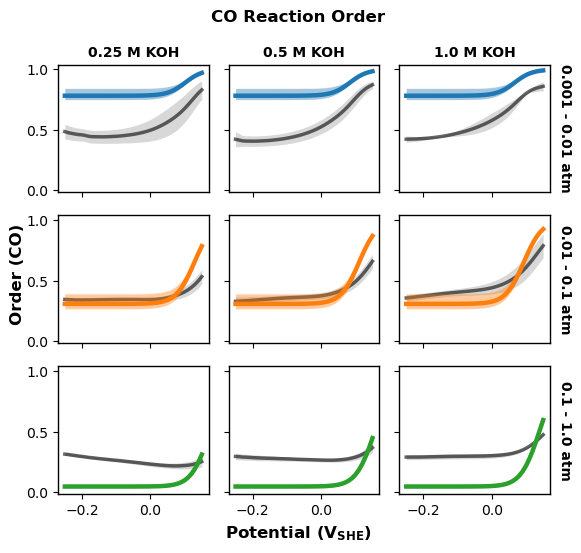

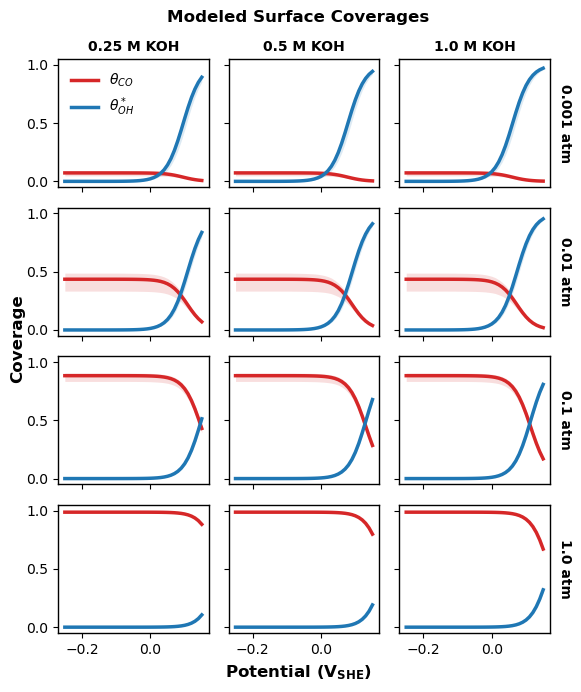

In [7]:
ppc_ER = plot_posteriors(trace_ER, ER)
plot_model_fits(trace_ER, ppc_ER); plot_coverages(trace_ER)

# BF ER

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.40,7
,3000,0,0.39,15
,3000,0,0.35,15
,3000,0,0.36,31


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   380.36    51.10
p_loo       12.10        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



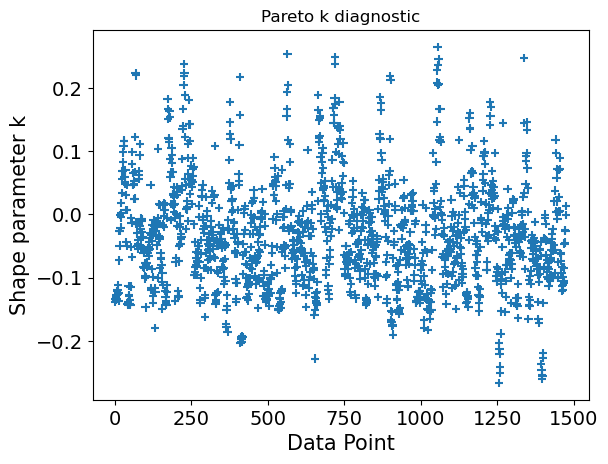

In [8]:
with pm.Model() as BF_ER:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH# -> COOH* + # (RDS) (BF)
    2b. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2_BF = Gact2_BF_0
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate = pt.logaddexp(log_rate_BF, log_rate_ER)
    rate = observables(log_rate) 

trace_BF_ER, loo_BF_ER = fit_and_evaluate(BF_ER)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.092  0.001  -0.094   -0.090      0.000    0.000    2026.0    2125.0    1.0
deltaG4_0   0.096  0.003   0.091    0.101      0.000    0.000    1787.0    2400.0    1.0
deltaG5_0  -0.107  0.005  -0.116   -0.098      0.000    0.000    1853.0    2298.0    1.0
Gact2_BF_0  0.734  0.002   0.731    0.738      0.000    0.000    1370.0    1819.0    1.0
Gact2_ER_0  0.713  0.001   0.711    0.714      0.000    0.000    1660.0    1941.0    1.0
beta_2      0.210  0.005   0.201    0.219      0.000    0.000    1488.0    2010.0    1.0
sigma_rel   0.204  0.009   0.187    0.221      0.000    0.000    2390.0    2733.0    1.0
sigma_base  0.047  0.003   0.042    0.052      0.000    0.000    2864.0    2691.0    1.0
exponent    2.145  0.094   1.975    2.329      0.002    0.001    2823.0    2638.0    1.0


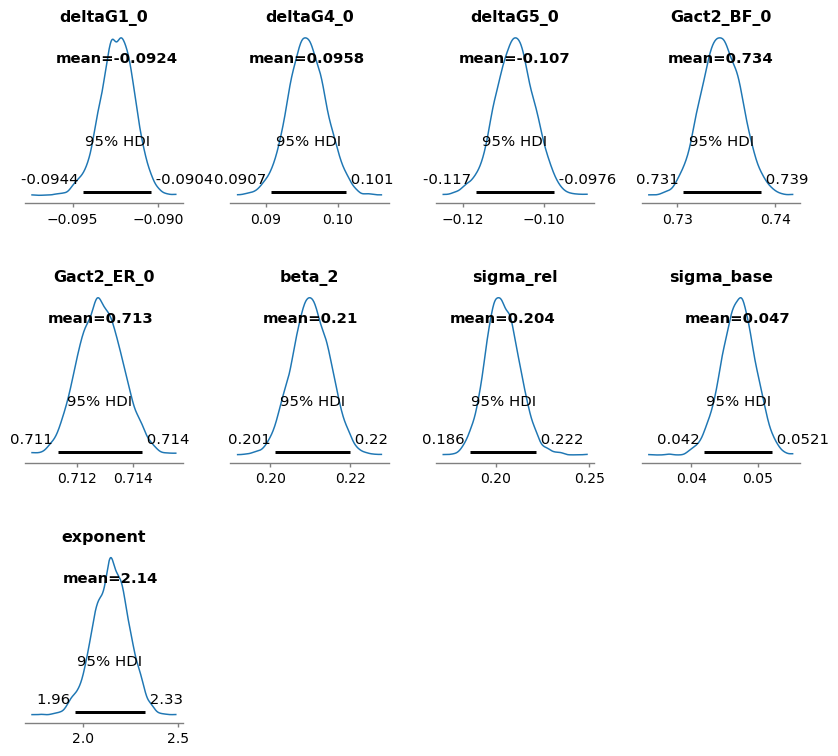

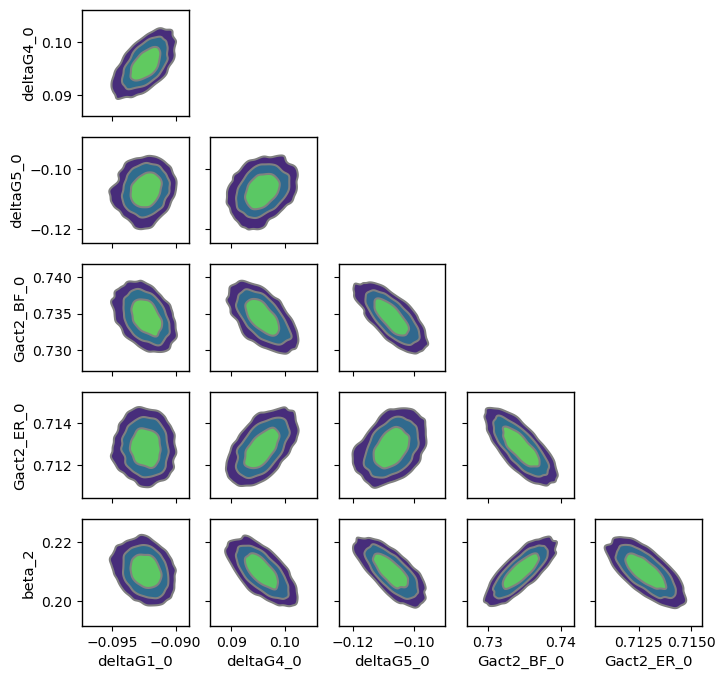

Sampling: [rate]


rate: 0.817


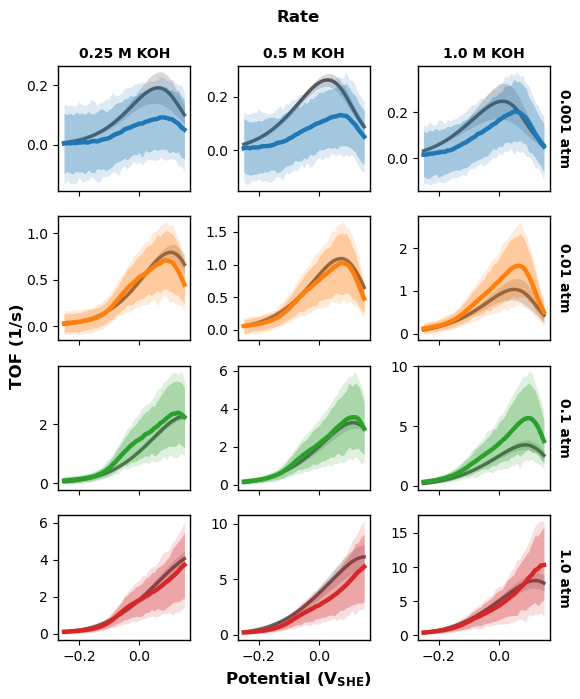

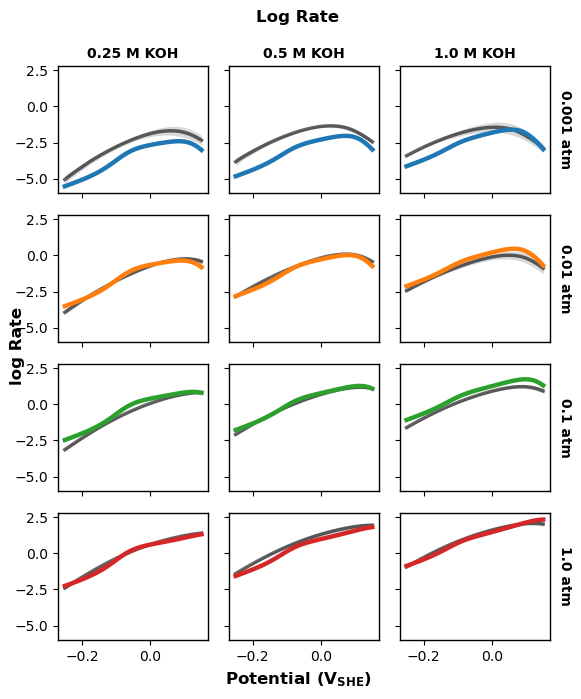

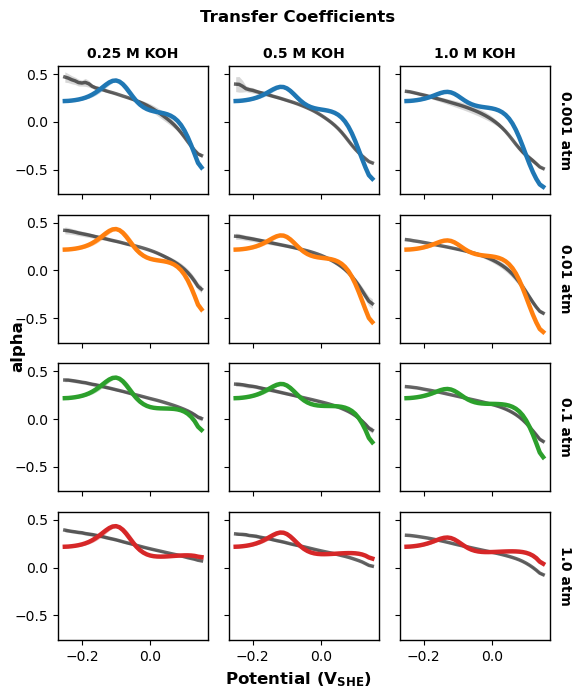

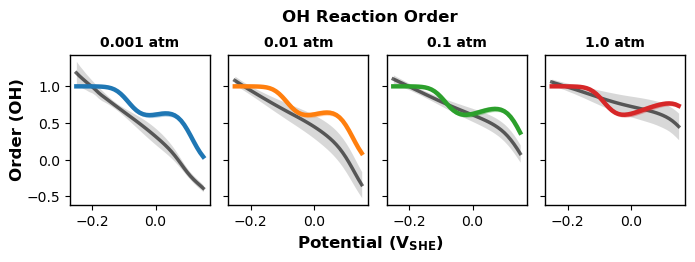

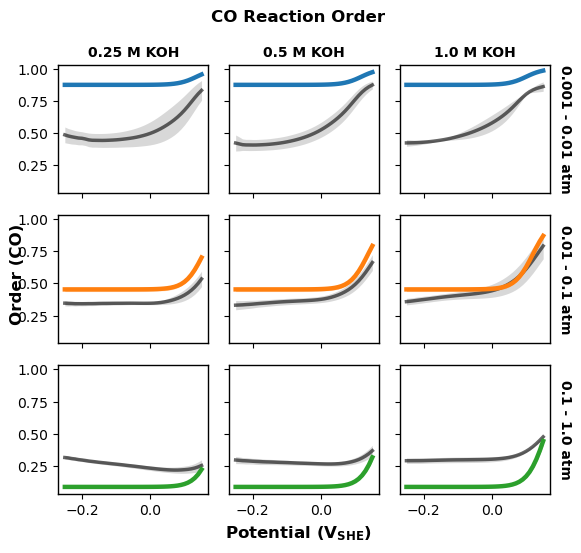

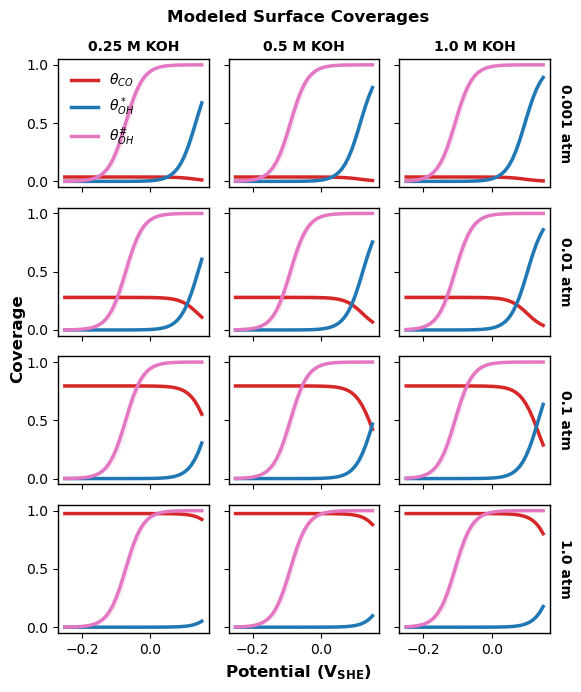

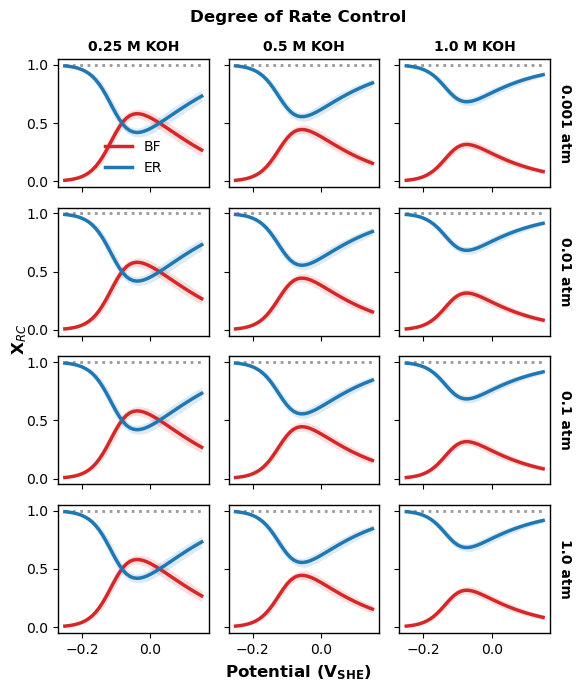

In [9]:
ppc_BF_ER = plot_posteriors(trace_BF_ER, BF_ER)
plot_model_fits(trace_BF_ER, ppc_BF_ER); plot_coverages(trace_BF_ER)
plot_drc(BF_ER, trace_BF_ER, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0'], perturb_labels=['BF', 'ER'])

# BF ER LH

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.37,7
,3000,0,0.43,15
,3000,0,0.39,15
,3000,0,0.40,7


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   414.04    50.82
p_loo       12.03        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



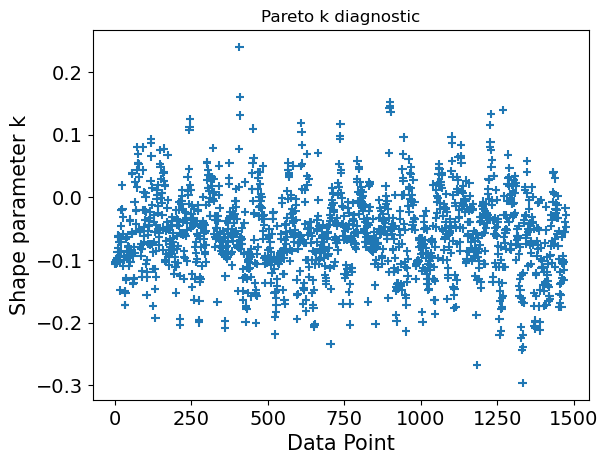

In [10]:
with pm.Model() as BF_ER_LH:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH# -> COOH* + # (RDS) (BF)
    2b. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    2c. CO* + OH* -> COOH* + * (RDS) (LH)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2) # at 0V_SHE
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2_BF = Gact2_BF_0
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH_Pd + np.log(1.0 - Ag_comp)
    log_rate = pt.logsumexp(pt.stack([log_rate_BF, log_rate_ER, log_rate_LH]), axis=0)
    rate = observables(log_rate) 

trace_BF_ER_LH, loo_BF_ER_LH = fit_and_evaluate(BF_ER_LH)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.090  0.001  -0.092   -0.089      0.000    0.000    2768.0    2663.0    1.0
deltaG4_0   0.082  0.002   0.078    0.086      0.000    0.000    2123.0    2830.0    1.0
deltaG5_0  -0.113  0.004  -0.122   -0.105      0.000    0.000    2253.0    2861.0    1.0
Gact2_BF_0  0.736  0.002   0.733    0.739      0.000    0.000    1628.0    2326.0    1.0
Gact2_ER_0  0.713  0.001   0.712    0.714      0.000    0.000    2376.0    2528.0    1.0
Gact2_LH_0  0.669  0.003   0.664    0.676      0.000    0.000    2997.0    2363.0    1.0
beta_2      0.208  0.004   0.200    0.215      0.000    0.000    1805.0    2538.0    1.0
sigma_rel   0.191  0.008   0.176    0.206      0.000    0.000    3600.0    3213.0    1.0
sigma_base  0.048  0.002   0.044    0.053      0.000    0.000    3884.0    2642.0    1.0
exponent    2.234  0.091   2.069    2.407      0.001    0.001    3973.0    3219.0    1.0


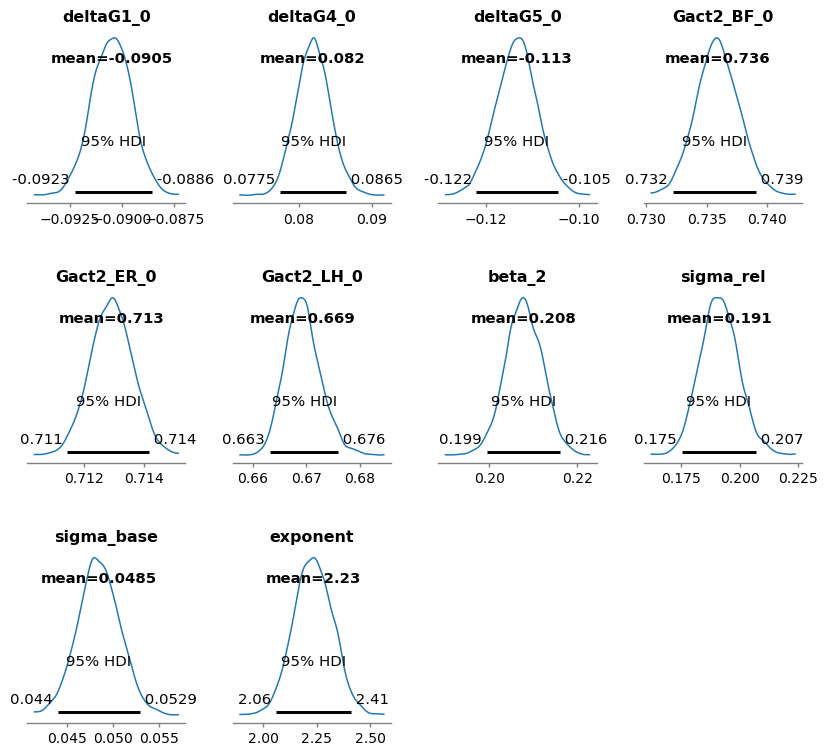

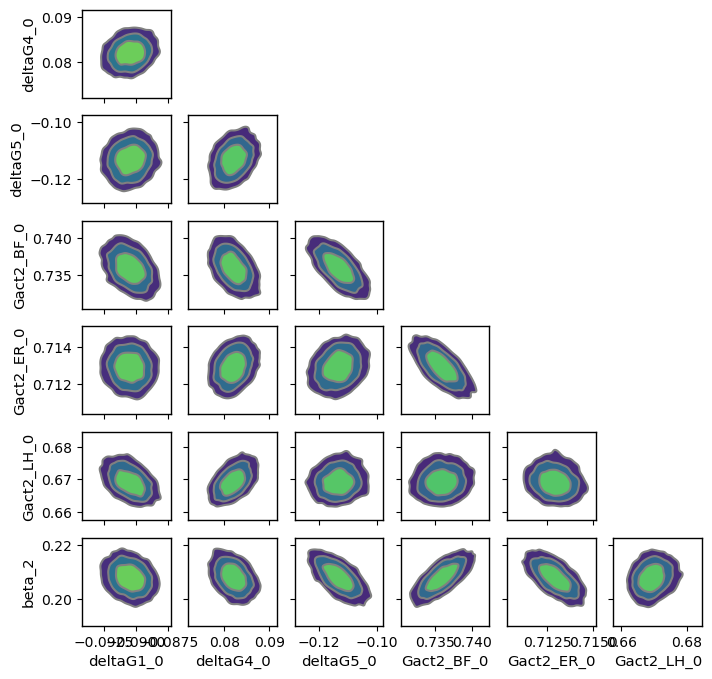

Sampling: [rate]


rate: 0.819


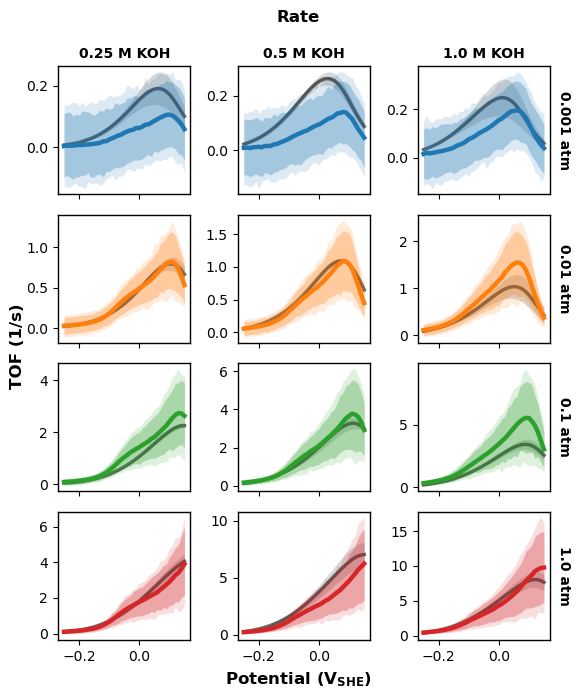

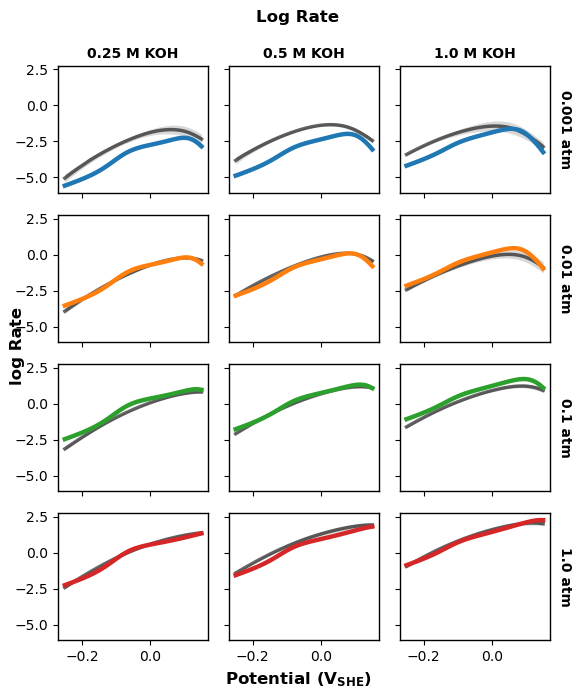

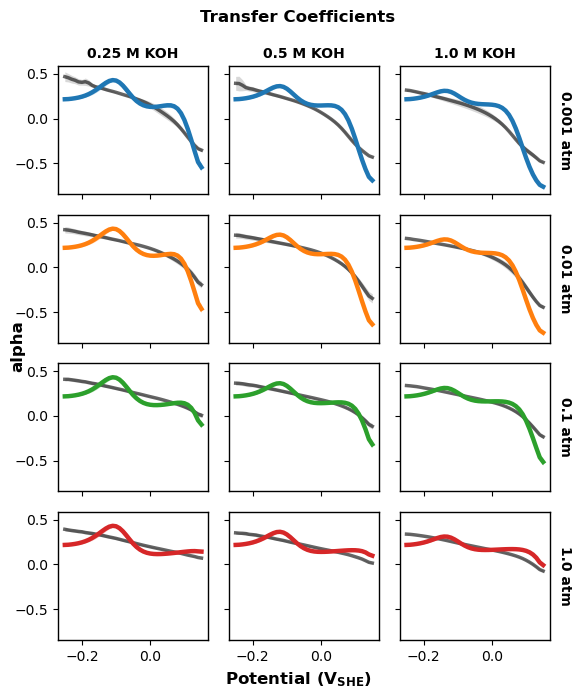

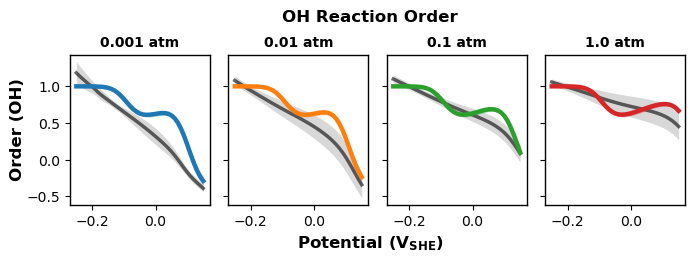

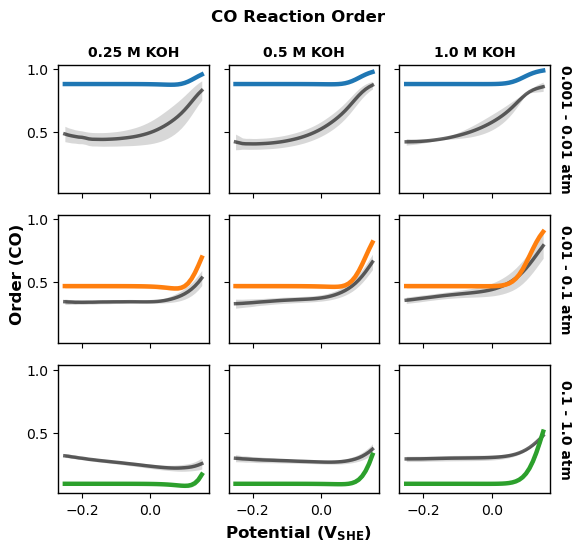

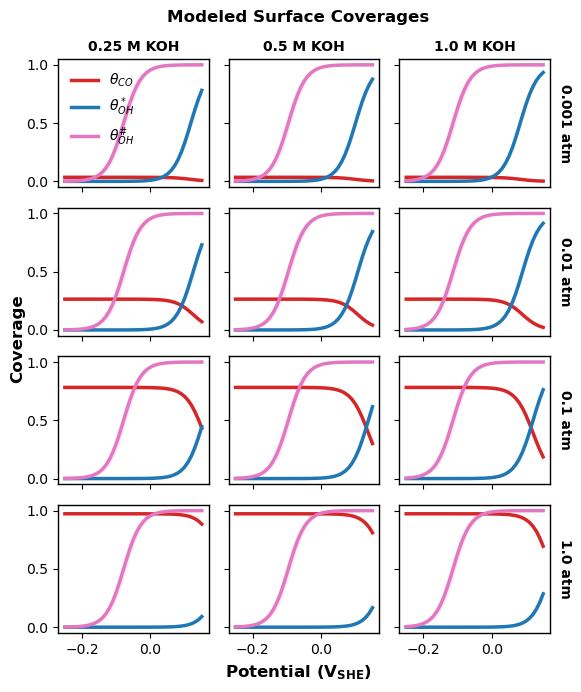

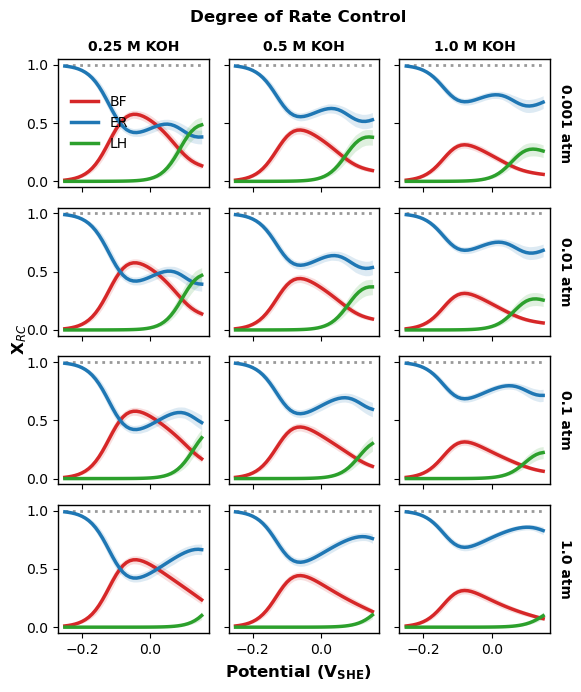

In [11]:
ppc_BF_ER_LH = plot_posteriors(trace_BF_ER_LH, BF_ER_LH)
plot_model_fits(trace_BF_ER_LH, ppc_BF_ER_LH); plot_coverages(trace_BF_ER_LH)
plot_drc(BF_ER_LH, trace_BF_ER_LH, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0', 'Gact2_LH_0'], perturb_labels=['BF', 'ER', 'LH'])

# BF PCT Ag

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.28,15
,3000,0,0.28,31
,3000,0,0.29,31
,3000,0,0.27,63


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   489.40    49.98
p_loo        9.33        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



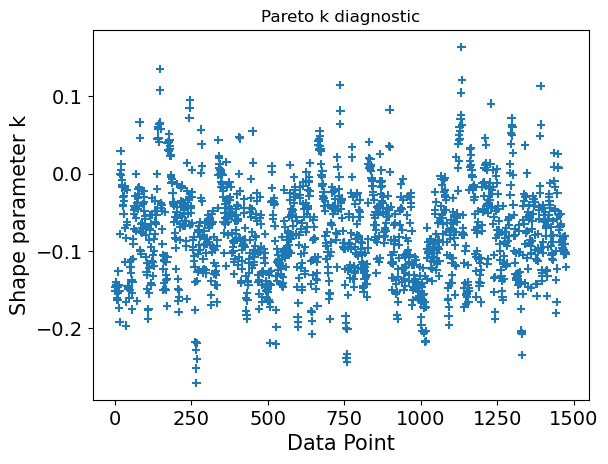

In [12]:
with pm.Model() as BF_PCT_Ag:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS) (BF)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2 = Gact2_0 - beta_2 * (1.0 - q) * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2 + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate = log_rate_BF
    rate = observables(log_rate) 

trace_BF_PCT_Ag, loo_BF_PCT_Ag = fit_and_evaluate(BF_PCT_Ag)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.090  0.001  -0.091   -0.088      0.000    0.000    2757.0    2658.0    1.0
deltaG4_0   0.108  0.003   0.103    0.113      0.000    0.000    1714.0    2340.0    1.0
deltaG5_0  -0.009  0.002  -0.012   -0.005      0.000    0.000    1259.0    1565.0    1.0
Gact2_0     0.687  0.001   0.685    0.689      0.000    0.000    1319.0    1629.0    1.0
beta_2      0.025  0.009   0.009    0.041      0.000    0.000    1567.0    1684.0    1.0
q           0.297  0.009   0.281    0.314      0.000    0.000    1488.0    1716.0    1.0
sigma_rel   0.165  0.008   0.150    0.178      0.000    0.000    3227.0    2365.0    1.0
sigma_base  0.051  0.002   0.047    0.055      0.000    0.000    4333.0    2779.0    1.0
exponent    2.528  0.102   2.328    2.711      0.002    0.001    2545.0    2631.0    1.0


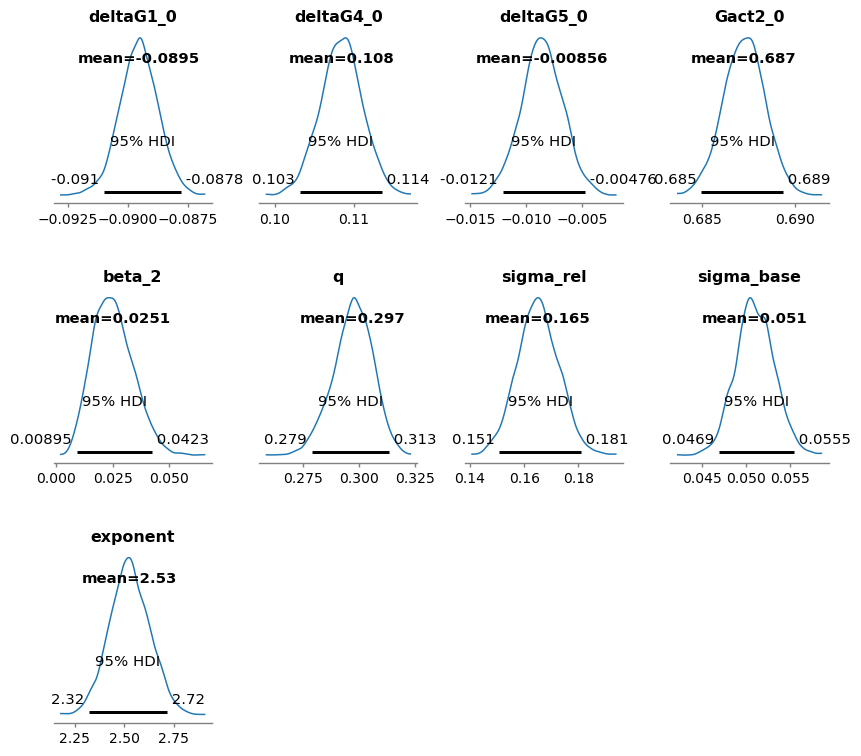

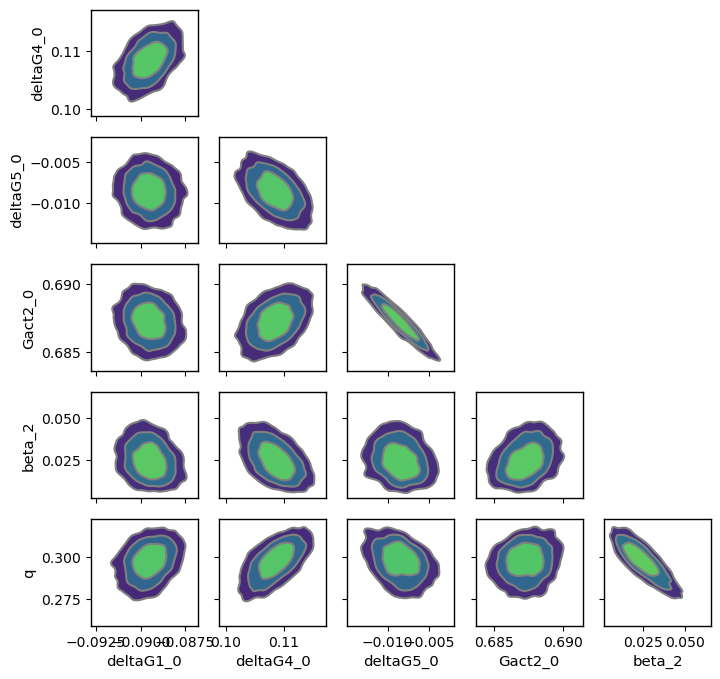

Sampling: [rate]


rate: 0.795


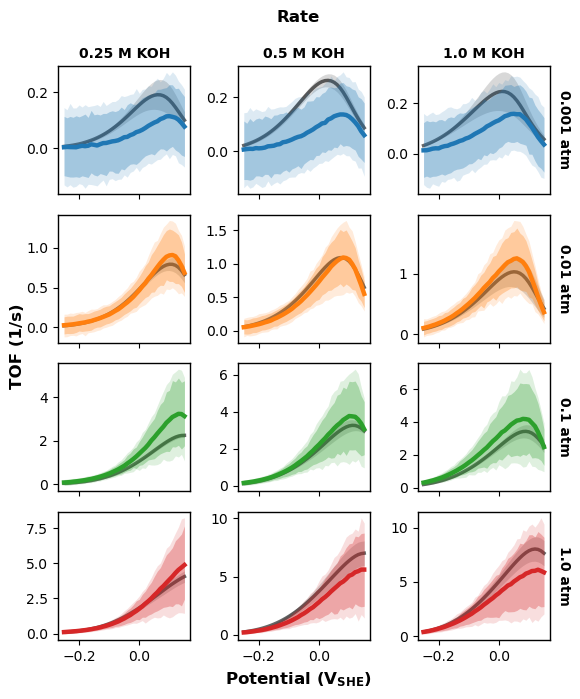

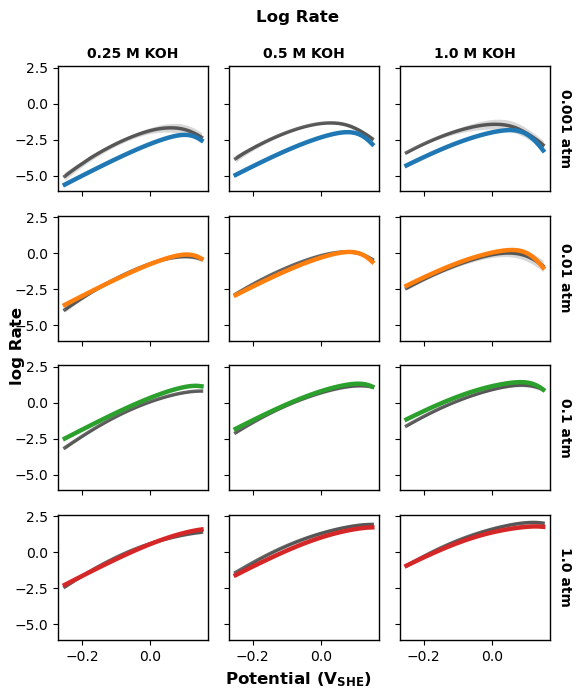

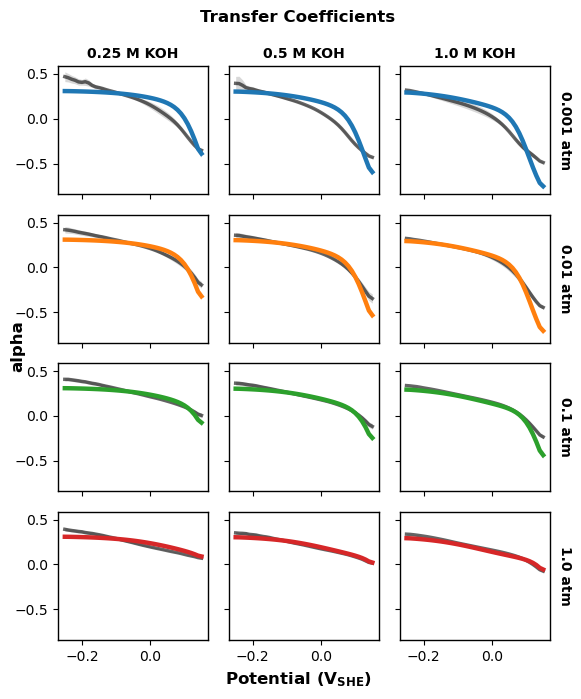

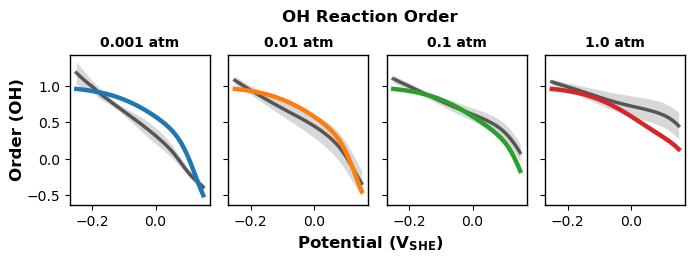

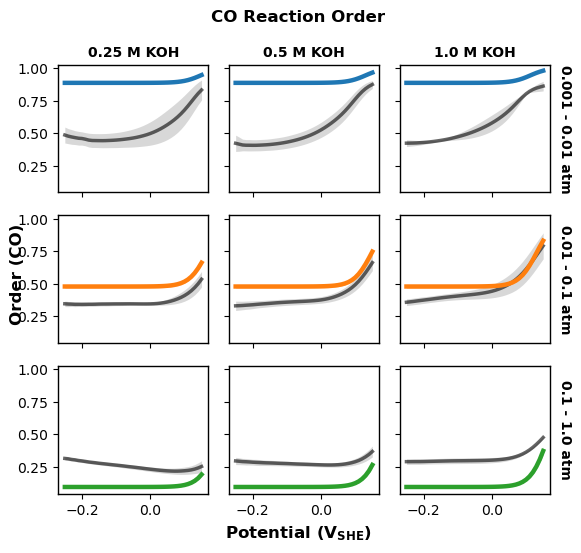

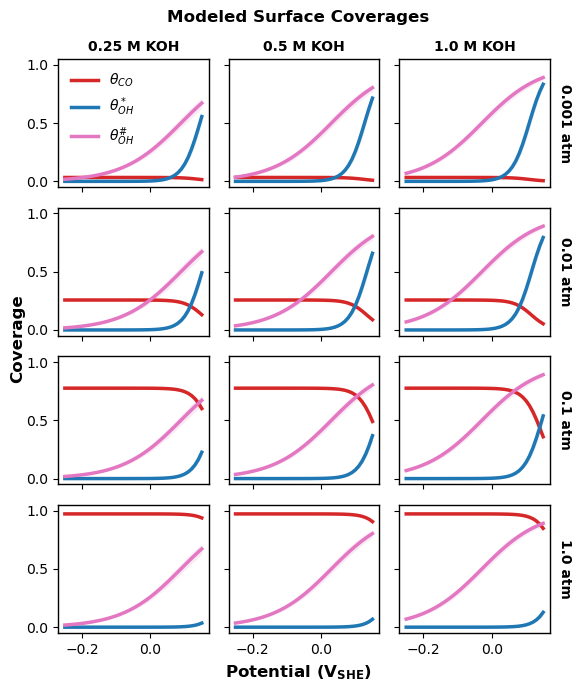

In [13]:
ppc_BF_PCT_Ag = plot_posteriors(trace_BF_PCT_Ag, BF_PCT_Ag)
plot_model_fits(trace_BF_PCT_Ag, ppc_BF_PCT_Ag); plot_coverages(trace_BF_PCT_Ag)

# BF LH PCT Ag

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.20,15
,3000,4,0.16,31
,3000,4,0.19,31
,3000,2,0.20,3


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   489.59    49.98
p_loo        9.05        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



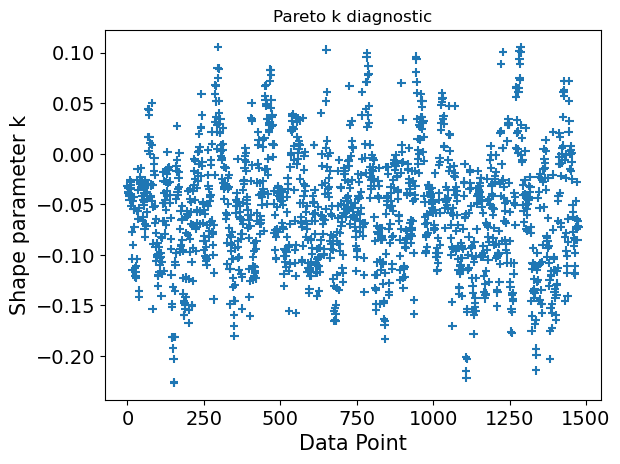

In [ ]:
with pm.Model() as BF_LH_PCT_Ag:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS) (BF)
    2b. CO* + OH* -> COOH* + * (RDS) (LH)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2_BF = Gact2_BF_0 - beta_2 * (1.0 - q) * E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH_Pd + np.log(1.0 - Ag_comp)
    log_rate = pt.logaddexp(log_rate_BF, log_rate_LH)
    rate = observables(log_rate) 

trace_BF_LH_PCT_Ag, loo_BF_LH_PCT_Ag = fit_and_evaluate(BF_LH_PCT_Ag, target_accept=0.95)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.090  0.001  -0.091   -0.088      0.000    0.000    2618.0    2299.0    1.0
deltaG4_0   0.108  0.003   0.104    0.113      0.000    0.000    1502.0    2284.0    1.0
deltaG5_0  -0.009  0.002  -0.012   -0.005      0.000    0.000     988.0    1263.0    1.0
Gact2_BF_0  0.687  0.001   0.685    0.689      0.000    0.000    1000.0    1388.0    1.0
Gact2_LH_0  0.879  0.114   0.710    1.087      0.003    0.002    1966.0    2125.0    1.0
beta_2      0.025  0.009   0.009    0.041      0.000    0.000    1310.0    1658.0    1.0
q           0.298  0.008   0.281    0.313      0.000    0.000    1306.0    2088.0    1.0
sigma_rel   0.165  0.008   0.152    0.180      0.000    0.000    2754.0    2717.0    1.0
sigma_base  0.051  0.002   0.047    0.055      0.000    0.000    3785.0    2526.0    1.0
exponent    2.530  0.103   2.327    2.714      0.002    0.002    2176.0    1878.0    1.0


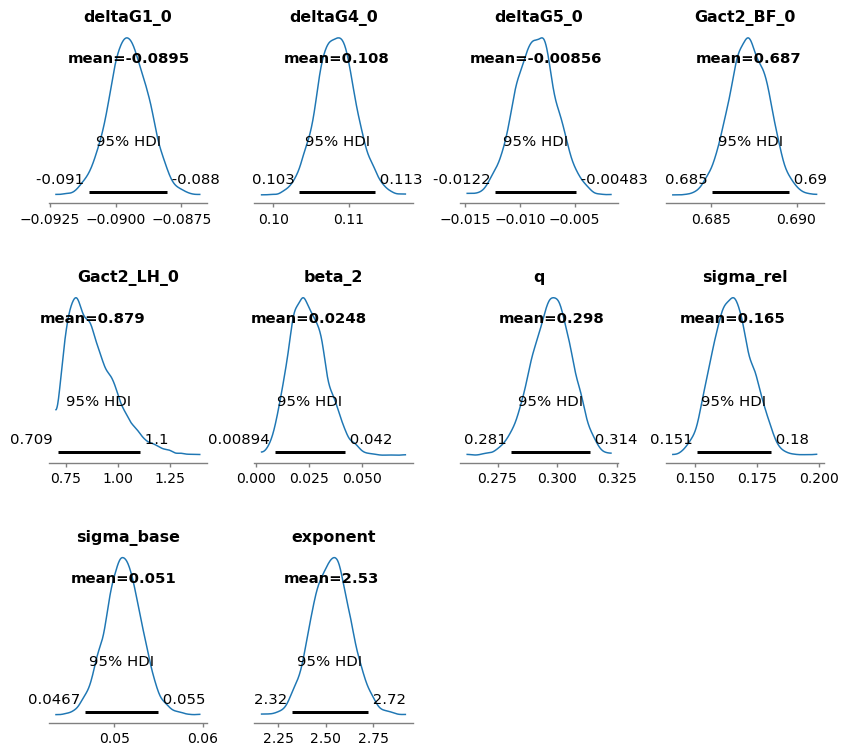

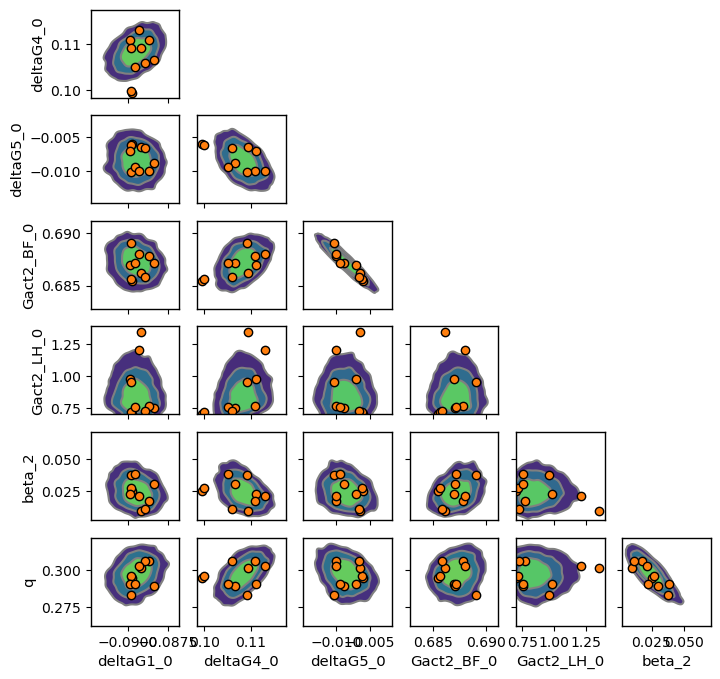

Sampling: [rate]


rate: 0.795


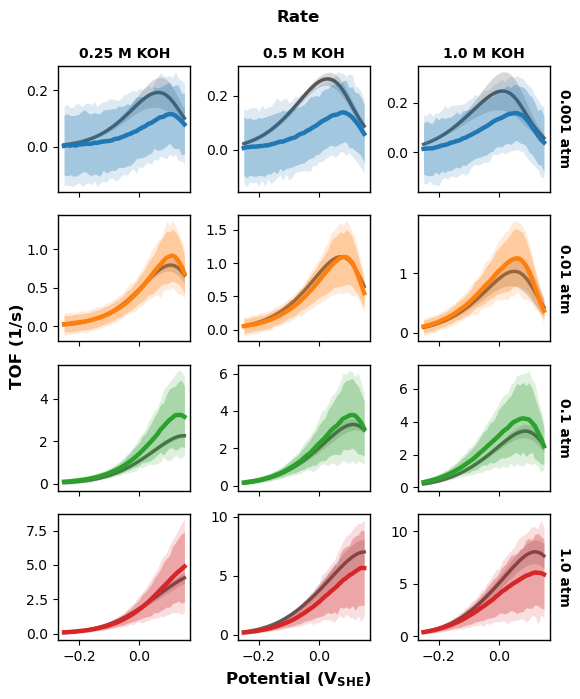

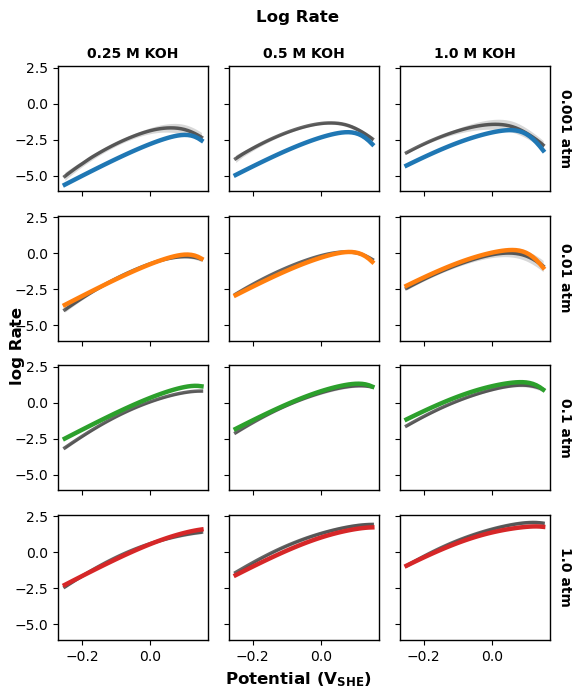

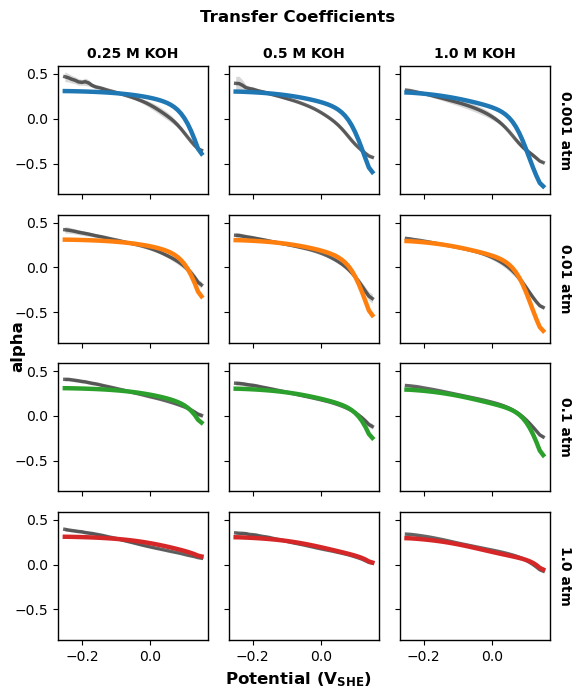

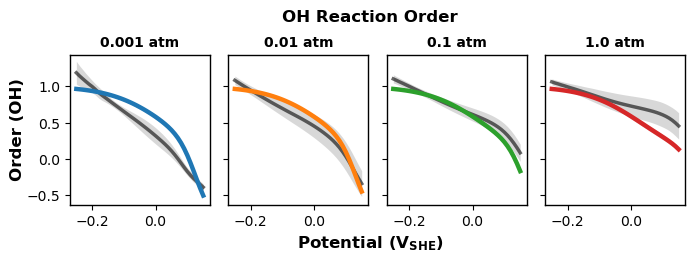

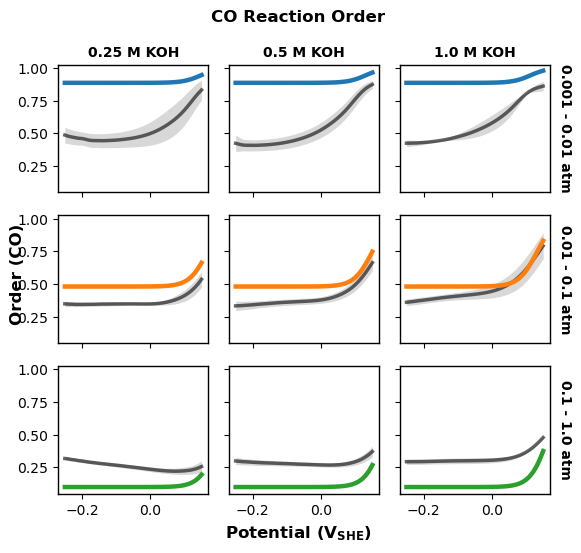

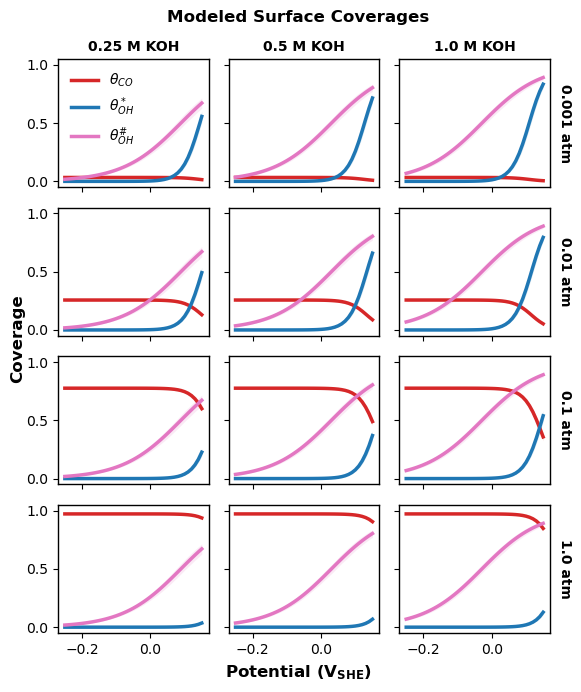

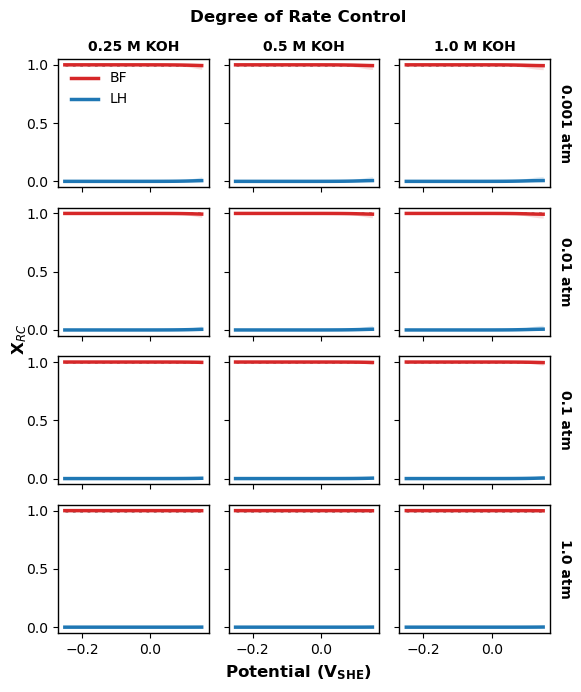

In [15]:
ppc_BF_LH_PCT_Ag = plot_posteriors(trace_BF_LH_PCT_Ag, BF_LH_PCT_Ag)
plot_model_fits(trace_BF_LH_PCT_Ag, ppc_BF_LH_PCT_Ag); plot_coverages(trace_BF_LH_PCT_Ag)
plot_drc(BF_LH_PCT_Ag, trace_BF_LH_PCT_Ag, perturb_vars=['Gact2_BF_0', 'Gact2_LH_0'], perturb_labels=['BF', 'LH'])

# BF ER PCT Ag

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.13,31
,3000,0,0.13,15
,3000,0,0.12,63
,3000,0,0.14,127


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   496.75    49.93
p_loo       10.59        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



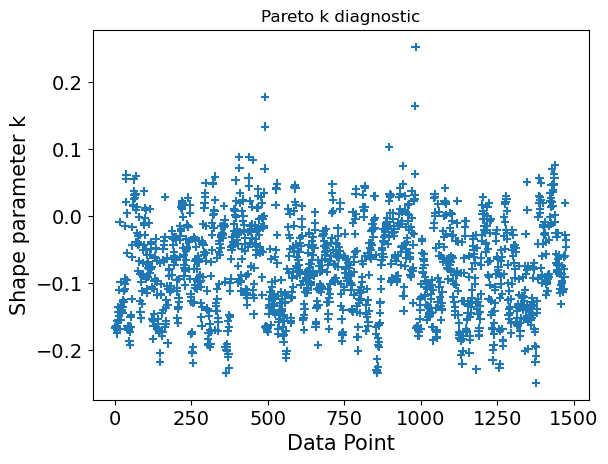

In [16]:
with pm.Model() as BF_ER_PCT_Ag:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS) (BF)
    2b. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
     # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2_BF = pm.Beta('beta_2_BF', alpha=5, beta=5)
    beta_2_ER = pm.Beta('beta_2_ER', alpha=5, beta=5)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2_BF = Gact2_BF_0 - beta_2_BF * (1.0 - q) * E_in
    Gact2_ER = Gact2_ER_0 - beta_2_ER * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate = pt.logaddexp(log_rate_BF, log_rate_ER)
    rate = observables(log_rate) 

trace_BF_ER_PCT_Ag, loo_BF_ER_PCT_Ag = fit_and_evaluate(BF_ER_PCT_Ag, target_accept=0.95)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.090  0.001  -0.091   -0.088      0.000    0.000    3273.0    2980.0   1.00
deltaG4_0   0.106  0.003   0.101    0.110      0.000    0.000    2439.0    2765.0   1.00
deltaG5_0  -0.018  0.004  -0.025   -0.010      0.000    0.000     420.0     330.0   1.01
Gact2_BF_0  0.696  0.003   0.689    0.702      0.000    0.000     369.0     226.0   1.01
Gact2_ER_0  0.759  0.023   0.735    0.786      0.002    0.005     370.0     176.0   1.01
beta_2_BF   0.020  0.008   0.006    0.034      0.000    0.000    2019.0    2186.0   1.00
beta_2_ER   0.280  0.071   0.202    0.364      0.005    0.010     520.0     230.0   1.01
q           0.323  0.013   0.298    0.347      0.001    0.000     551.0     752.0   1.00
sigma_rel   0.166  0.008   0.151    0.180      0.000    0.000    3908.0    3217.0   1.00
sigma_base  0.050  0.002   0.046    0.054      0.000    0.000    4728.0    3291.0   1.00
exponent    2.477  0.

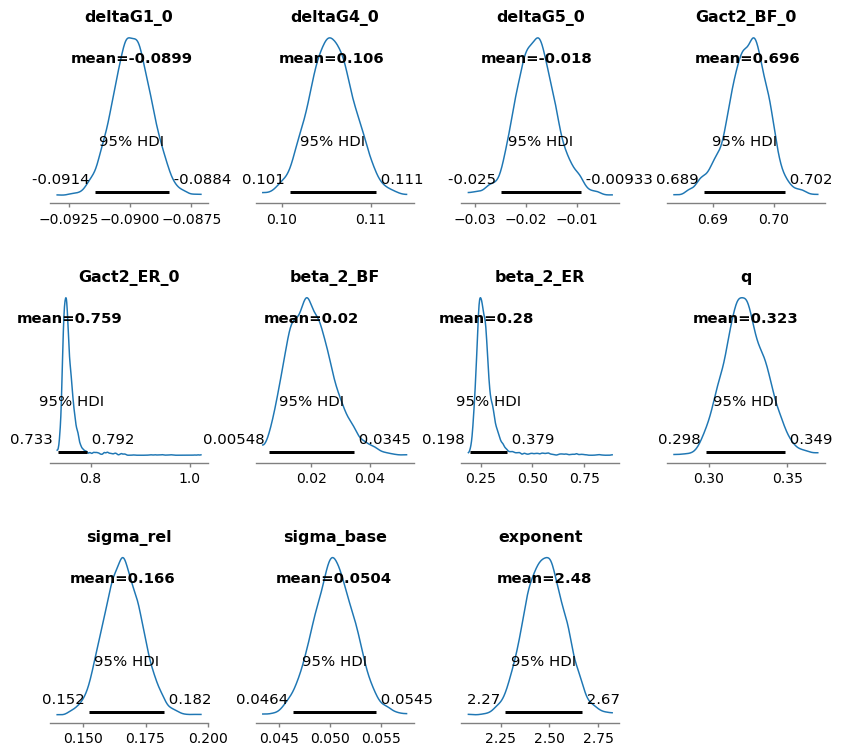

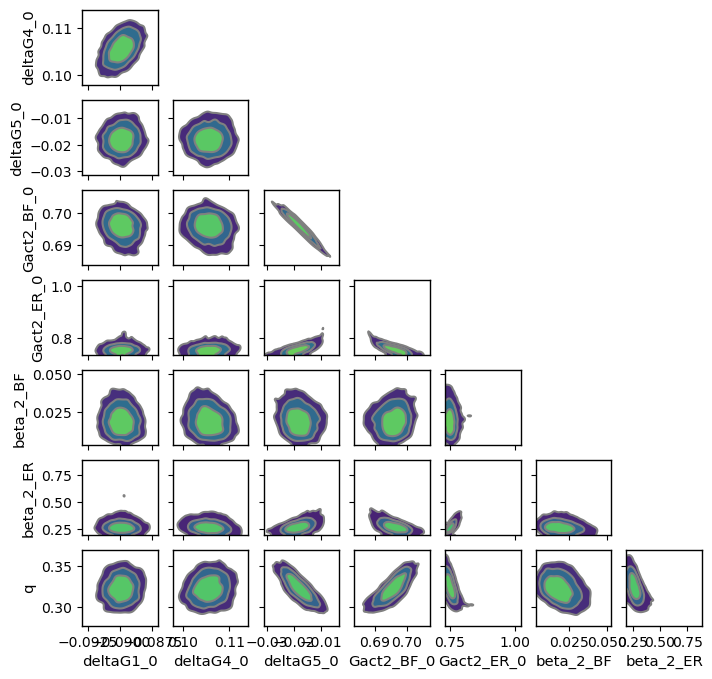

Sampling: [rate]


rate: 0.806


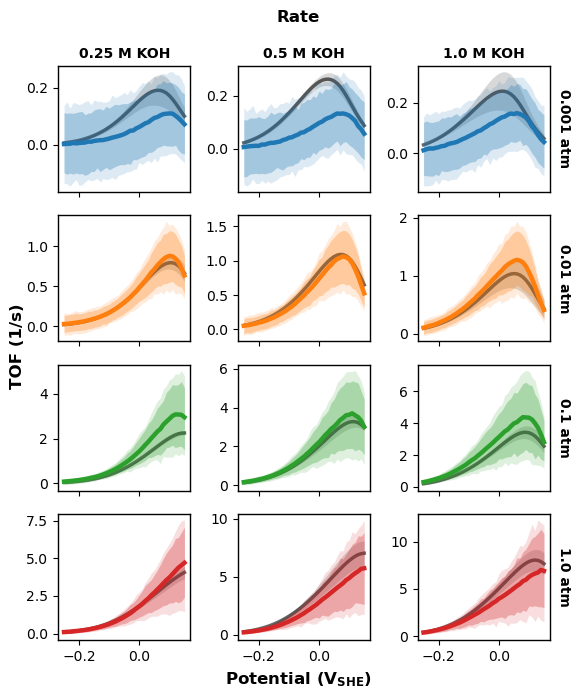

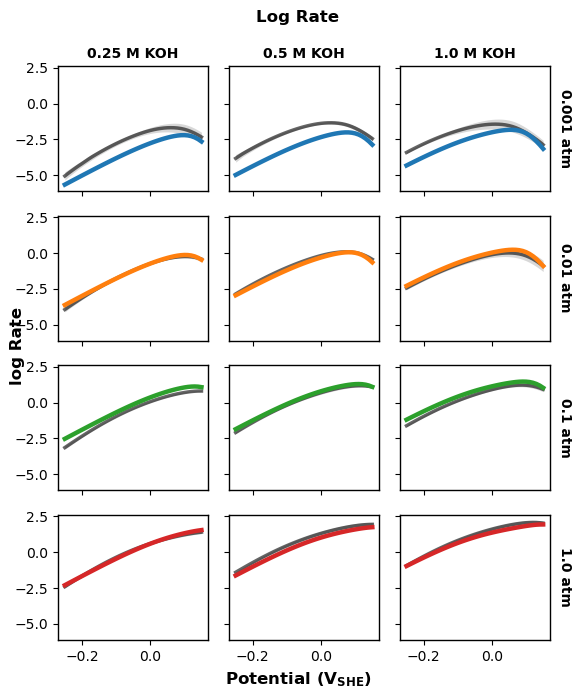

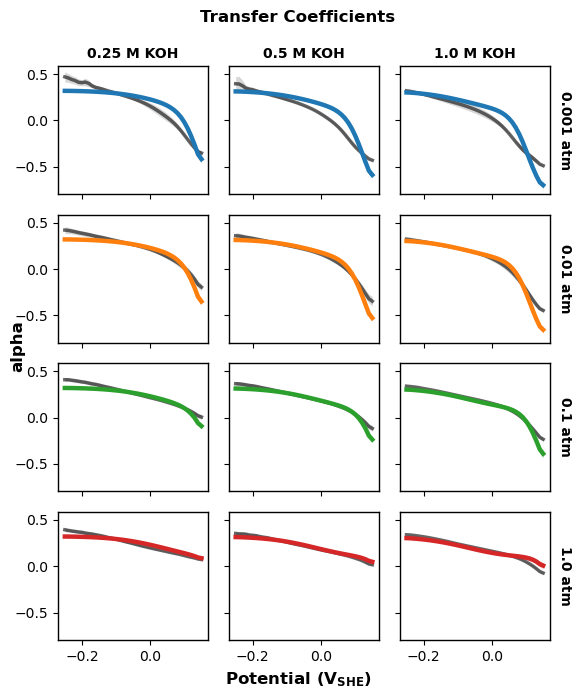

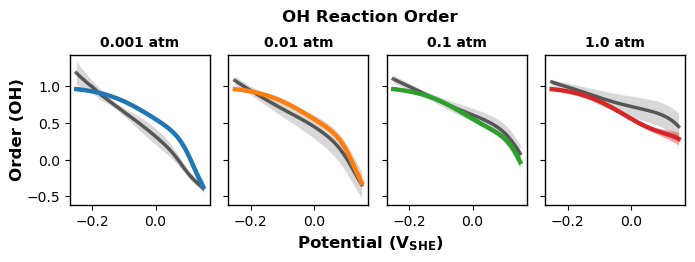

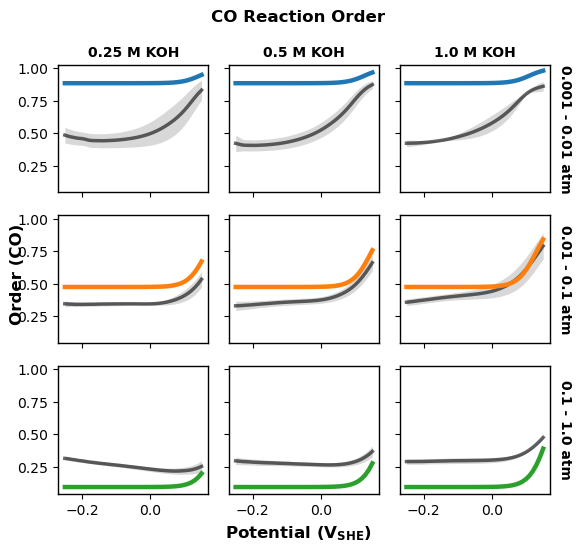

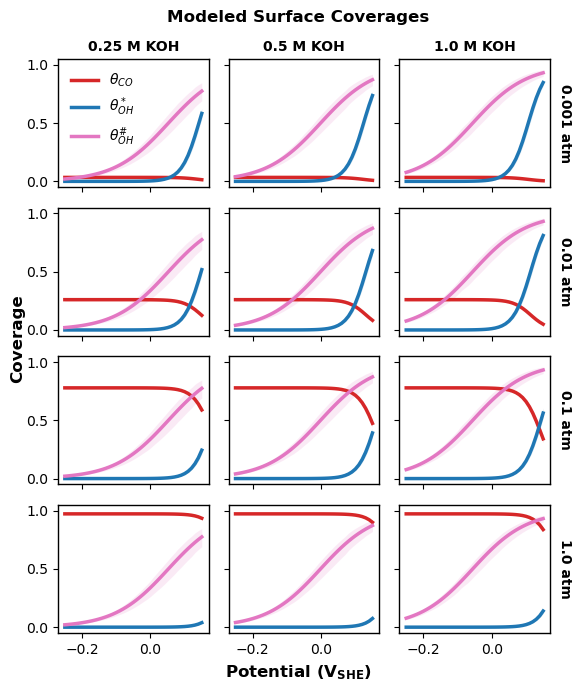

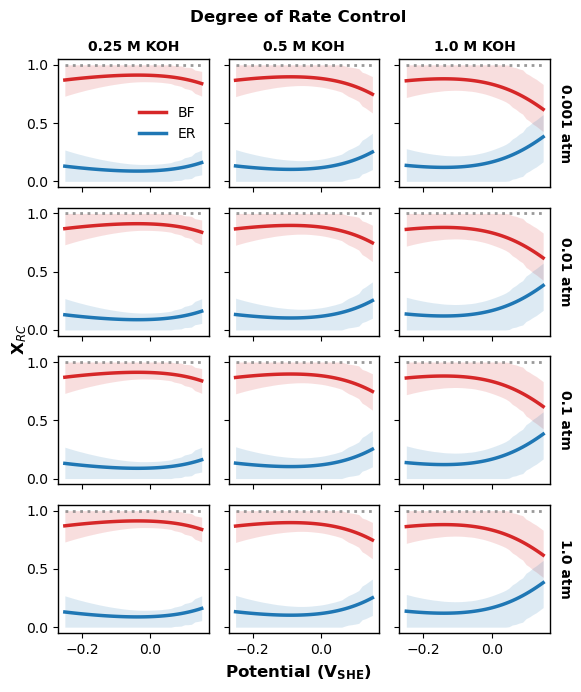

In [17]:
ppc_BF_ER_PCT_Ag = plot_posteriors(trace_BF_ER_PCT_Ag, BF_ER_PCT_Ag)
plot_model_fits(trace_BF_ER_PCT_Ag, ppc_BF_ER_PCT_Ag); plot_coverages(trace_BF_ER_PCT_Ag)
plot_drc(BF_ER_PCT_Ag, trace_BF_ER_PCT_Ag, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0'], perturb_labels=['BF', 'ER'])

# BF LH ER PCT Ag

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.07,63
,3000,0,0.07,63
,3000,0,0.06,63
,3000,0,0.06,63


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   496.52    49.95
p_loo       10.88        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



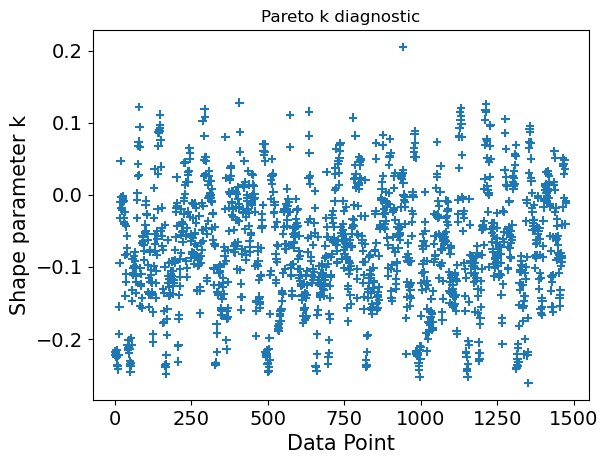

In [18]:
with pm.Model() as BF_LH_ER_PCT_Ag:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS) (BF)
    2b. CO* + OH* -> COOH* + * (RDS) (LH)
    2c. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2_BF = pm.Beta('beta_2_BF', alpha=5, beta=5)
    beta_2_ER = pm.Beta('beta_2_ER', alpha=5, beta=5)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2_BF = Gact2_BF_0 - beta_2_BF * (1.0 - q) * E_in
    Gact2_LH = Gact2_LH_0
    Gact2_ER = Gact2_ER_0 - beta_2_ER * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH_Pd + np.log(1.0 - Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate = pt.logsumexp(pt.stack([log_rate_BF, log_rate_LH, log_rate_ER]), axis=0)
    rate = observables(log_rate) 

trace_BF_LH_ER_PCT_Ag, loo_BF_LH_ER_PCT_Ag = fit_and_evaluate(BF_LH_ER_PCT_Ag, target_accept=0.99)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.090  0.001  -0.091   -0.089      0.000    0.000    3197.0    2523.0   1.00
deltaG4_0   0.105  0.003   0.100    0.111      0.000    0.000    2243.0    2124.0   1.00
deltaG5_0  -0.018  0.004  -0.025   -0.010      0.000    0.000     375.0     261.0   1.01
Gact2_BF_0  0.696  0.003   0.688    0.701      0.000    0.000     351.0     224.0   1.01
Gact2_LH_0  0.871  0.119   0.693    1.088      0.003    0.002    1784.0    1773.0   1.00
Gact2_ER_0  0.761  0.035   0.737    0.796      0.003    0.012     331.0     172.0   1.01
beta_2_BF   0.020  0.008   0.006    0.034      0.000    0.000    2383.0    2094.0   1.00
beta_2_ER   0.279  0.064   0.201    0.385      0.005    0.009     521.0     237.0   1.01
q           0.323  0.014   0.297    0.348      0.001    0.000     438.0     543.0   1.01
sigma_rel   0.166  0.008   0.151    0.180      0.000    0.000    3443.0    3347.0   1.00
sigma_base  0.050  0.

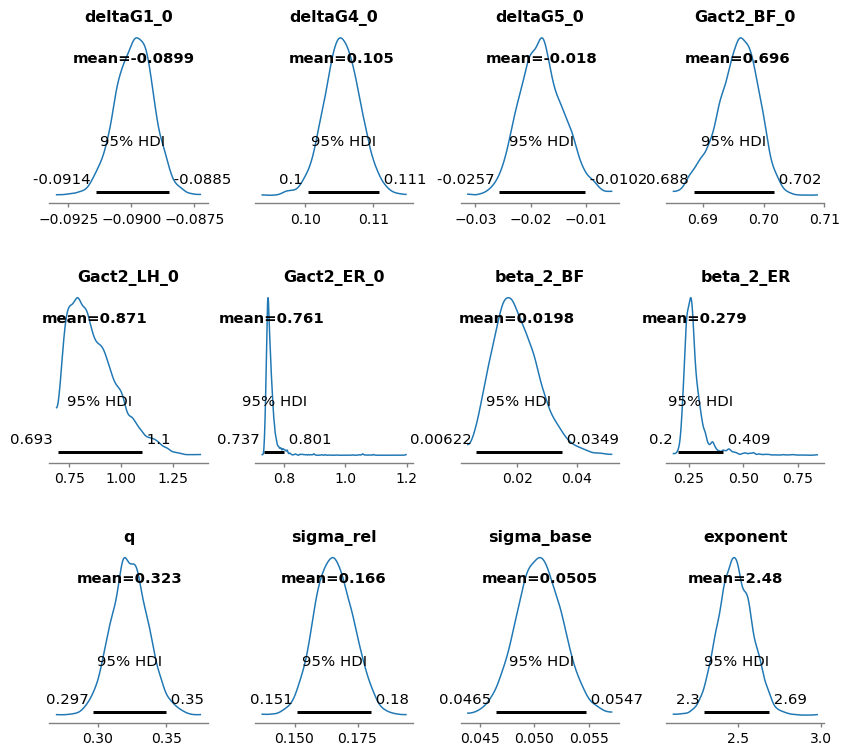

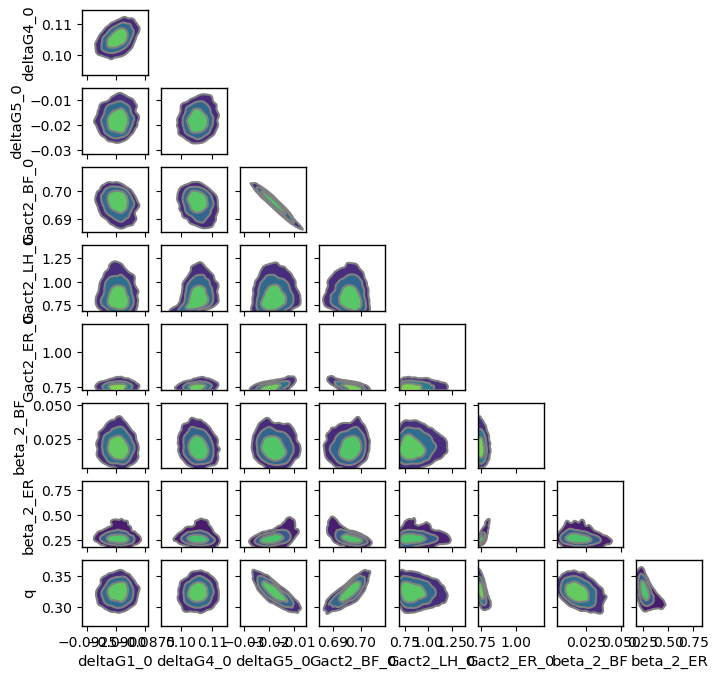

Sampling: [rate]


rate: 0.807


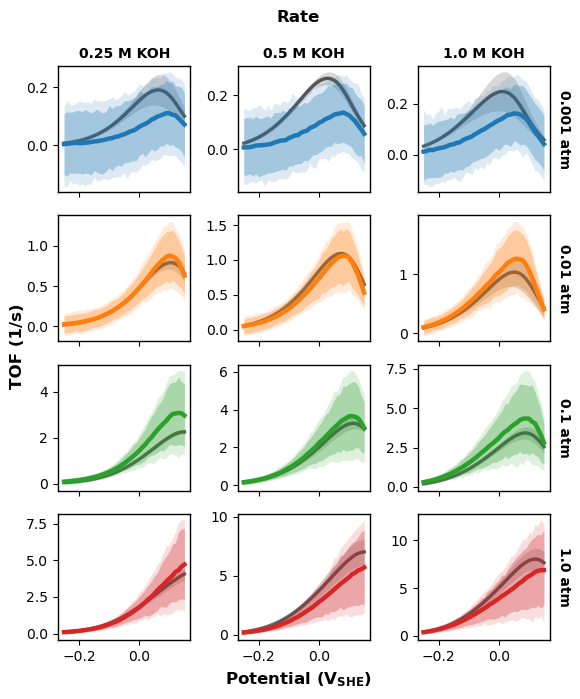

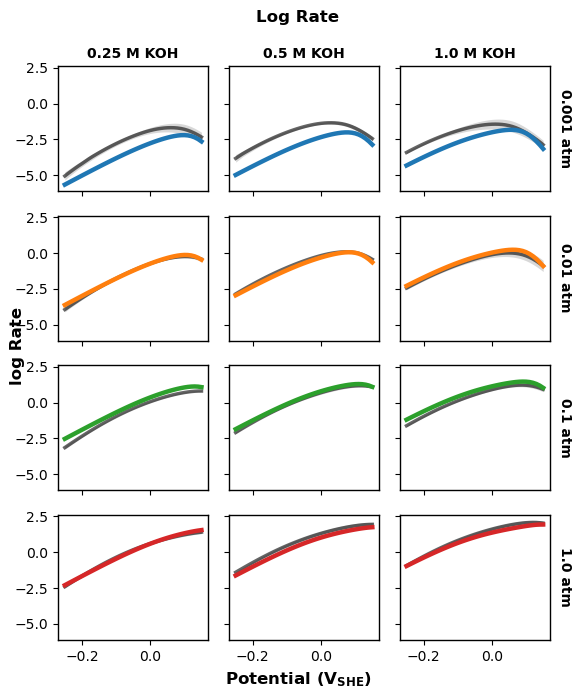

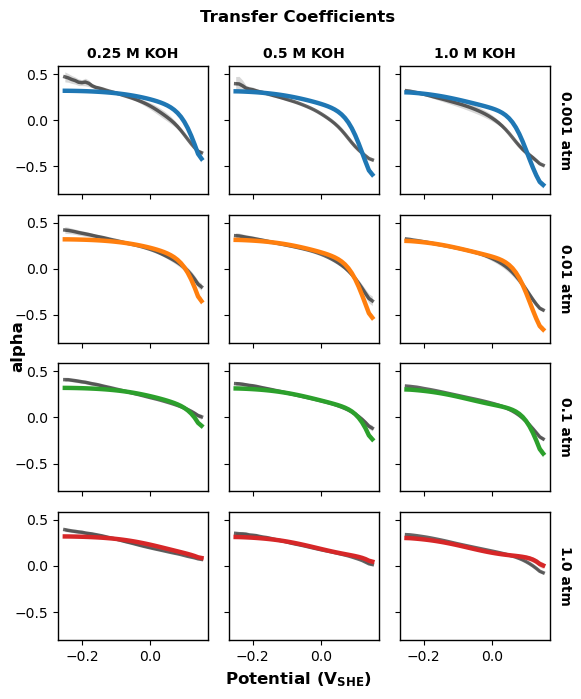

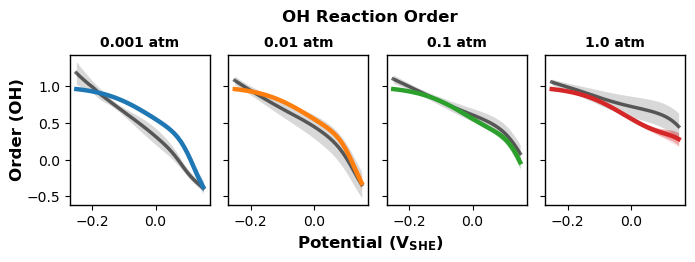

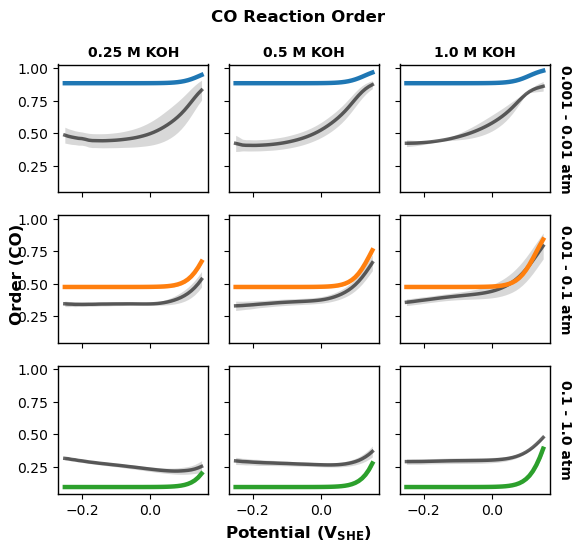

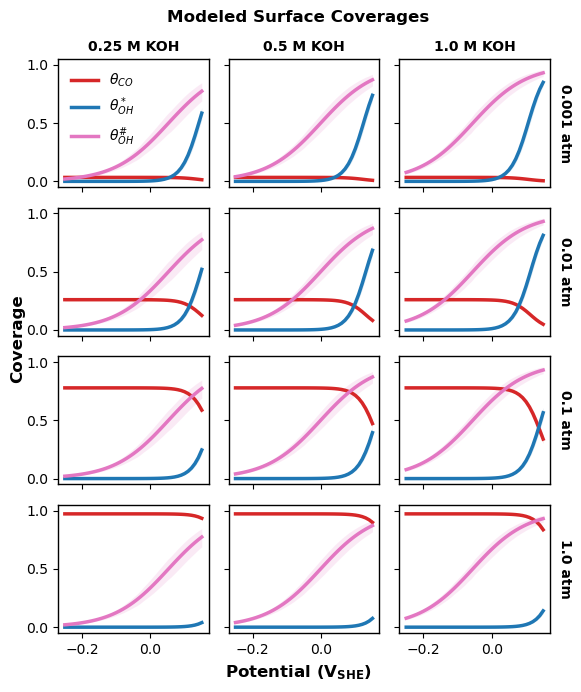

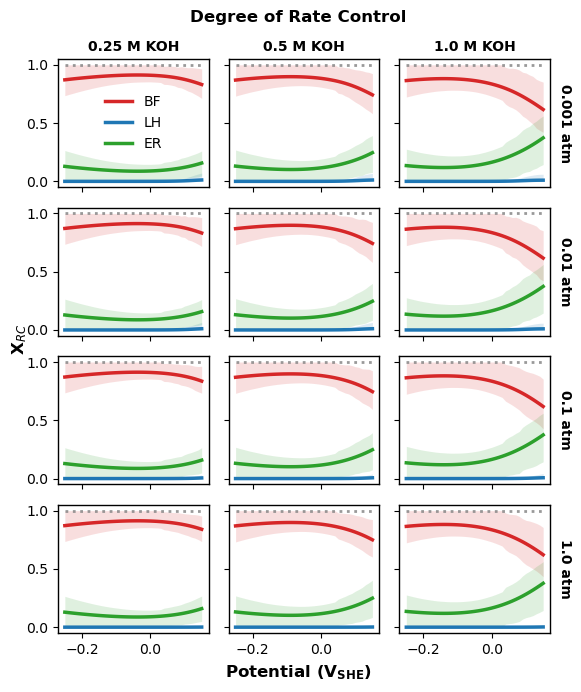

In [19]:
ppc_BF_LH_ER_PCT_Ag = plot_posteriors(trace_BF_LH_ER_PCT_Ag, BF_LH_ER_PCT_Ag)
plot_model_fits(trace_BF_LH_ER_PCT_Ag, ppc_BF_LH_ER_PCT_Ag); plot_coverages(trace_BF_LH_ER_PCT_Ag)
plot_drc(BF_LH_ER_PCT_Ag, trace_BF_LH_ER_PCT_Ag, perturb_vars=['Gact2_BF_0', 'Gact2_LH_0', 'Gact2_ER_0'], perturb_labels=['BF', 'LH', 'ER'])

# CO BF PCT Ag 

In [20]:
with pm.Model() as CO_BF_PCT_Ag:
    '''
    1. CO + * <-> CO* (SSA)
    2. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact1_0 = pm.Normal('Gact1_0', mu=0.7, sigma=0.2)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact1 = Gact1_0
    Gact2 = Gact2_0 - beta_2 * (1.0 - q) * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k1 = np.log(kb_J*T/h) - Gact1/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_OH_Ag)
    log_theta_Ag = -pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    log_A_Pd = pt.logsumexp(pt.stack([zeros, term_OH_Pd]), axis=0) 
    log_k1_PCO = log_k1 + np.log(P_CO_in)                    
    log_k_minus_1 = log_k1 - log_K1                                
    log_k_BF_app = log_k2 + log_theta_OH_Ag + np.log(Ag_comp)     
    log_denom_Pd = pt.logsumexp(pt.stack([log_k1_PCO, log_A_Pd + log_k_minus_1, log_A_Pd + log_k_BF_app]), axis=0)

    # Calculate final coverages exactly
    log_theta_CO = log_k1_PCO - log_denom_Pd
    log_theta_Pd = pt.logsumexp(pt.stack([log_k_minus_1 + zeros, log_k_BF_app]), axis=0) - log_denom_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate = log_k_BF_app + log_theta_CO
    rate = observables(log_rate) 

# trace_CO_BF_PCT_Ag, loo_CO_BF_PCT_Ag = fit_and_evaluate(CO_BF_PCT_Ag)

In [21]:
# ppc_CO_BF_LH_PCT_Ag = plot_posteriors(trace_CO_BF_PCT_Ag, CO_BF_PCT_Ag)#
# plot_model_fits(trace_CO_BF_PCT_Ag, ppc_CO_BF_LH_PCT_Ag); plot_coverages(trace_CO_BF_PCT_Ag)
# plot_drc(CO_BF_PCT_Ag, trace_CO_BF_PCT_Ag, perturb_vars=['Gact2_0', 'Gact1_0'], perturb_labels=['BF', 'CO ads'])

# OH Ag BF PCT Ag

In [22]:
with pm.Model() as OH_Ag_BF_PCT_Ag:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (SSA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    beta_5 = pm.Beta('beta_5', alpha=5, beta=5)
    q = pm.Beta('q', alpha=10, beta=10)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)
    Gact5_0 = pm.Normal('Gact5_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2 = Gact2_0 - beta_2 * (1.0 - q) * E_in
    Gact5 = Gact5_0 - beta_5 * q * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k5 = np.log(kb_J*T/h) - Gact5/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_k5_CKOH = log_k5 + np.log(C_KOH_in)
    log_k_minus_5 = log_k5 - log_K5
    log_k2_theta_CO = log_k2 + log_theta_CO
    log_den_Ag = pt.logsumexp(pt.stack([log_k5_CKOH, log_k_minus_5, log_k2_theta_CO]), axis=0)
    log_theta_OH_Ag = log_k5_CKOH - log_den_Ag
    log_num_empty_Ag = pt.logsumexp(pt.stack([log_k_minus_5, log_k2_theta_CO]), axis=0)
    log_theta_empty_Ag = log_num_empty_Ag - log_den_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_empty_Ag))

    # Rate expression 
    log_rate = log_k2 + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    rate = observables(log_rate)
    
# trace_OH_Ag_BF_PCT_Ag, loo_OH_Ag_BF_PCT_Ag = fit_and_evaluate(OH_Ag_BF_PCT_Ag)

In [23]:
# ppc_OH_Ag_BF_PCT_Ag = plot_posteriors(trace_OH_Ag_BF_PCT_Ag, OH_Ag_BF_PCT_Ag)
# plot_model_fits(trace_OH_Ag_BF_PCT_Ag, ppc_OH_Ag_BF_PCT_Ag); plot_coverages(trace_OH_Ag_BF_PCT_Ag)
# plot_drc(OH_Ag_BF_PCT_Ag, trace_OH_Ag_BF_PCT_Ag, perturb_vars=['Gact2_0', 'Gact5_0'], perturb_labels=['BF', 'OH Ag ads'])

# BF LH PCT Ag Pd

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.22,31
,3000,0,0.24,47
,3000,0,0.23,47
,3000,0,0.22,31


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   442.75    54.15
p_loo       14.17        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



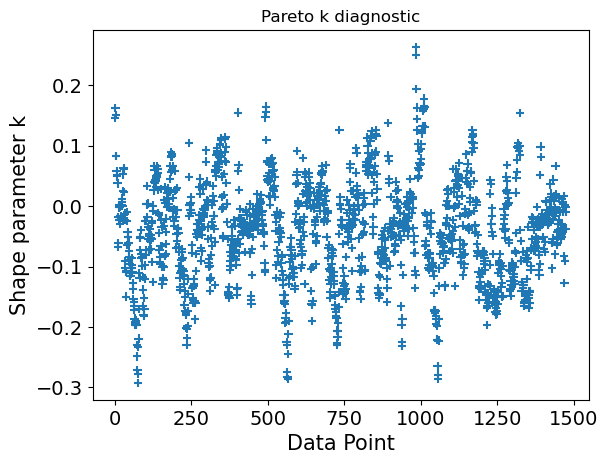

In [ ]:
with pm.Model() as BF_LH_PCT_Ag_Pd:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH(q5-1)# -> COOH* + # + (1-q5)(e-) (RDS) (BF)
    2b. CO* + OH(q4-1)* -> COOH* + * + (1-q4)(e-) (RDS) (LH)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH(q4-1)* + (q4)(e-) (QEA)
    5. OH- + # <-> OH(q5-1)# + (q5)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2_BF = pm.Beta('beta_2_BF', alpha=5, beta=5)
    # beta_2_LH = pm.Beta('beta_2_LH', alpha=5, beta=5)
    q4 = pm.Beta('q4', alpha=10, beta=1)
    q5 = pm.Beta('q5', alpha=1, beta=1)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    # Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - q4 * E_in
    deltaG5 = deltaG5_0 - q5 * E_in
    Gact2_BF = Gact2_BF_0 - beta_2_BF * (1.0 - q5) * E_in
    # Gact2_LH = Gact2_LH_0 - beta_2_LH * (1.0 - q4) * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    # log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    # log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH_Pd + np.log(1.0 - Ag_comp)
    # log_rate = pt.logaddexp(log_rate_BF, log_rate_LH)
    rate = observables(log_rate_BF) 

trace_BF_LH_PCT_Ag_Pd, loo_BF_LH_PCT_Ag_Pd = fit_and_evaluate(BF_LH_PCT_Ag_Pd)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.113  0.002  -0.116   -0.109      0.000    0.000    2114.0    2153.0    1.0
deltaG4_0   0.011  0.005   0.002    0.019      0.000    0.000    1656.0    2248.0    1.0
deltaG5_0   0.007  0.002   0.003    0.012      0.000    0.000    1512.0    1932.0    1.0
Gact2_BF_0  0.680  0.002   0.677    0.683      0.000    0.000    1463.0    1809.0    1.0
beta_2_BF   0.037  0.013   0.014    0.061      0.000    0.000    1786.0    2052.0    1.0
q4          0.542  0.030   0.490    0.602      0.001    0.000    1930.0    2153.0    1.0
q5          0.272  0.011   0.252    0.293      0.000    0.000    1990.0    2243.0    1.0
sigma_rel   0.275  0.008   0.261    0.291      0.000    0.000    3401.0    3244.0    1.0
sigma_base  0.001  0.001   0.000    0.003      0.000    0.000    2957.0    1592.0    1.0
exponent    1.648  0.064   1.522    1.761      0.001    0.001    2308.0    2710.0    1.0


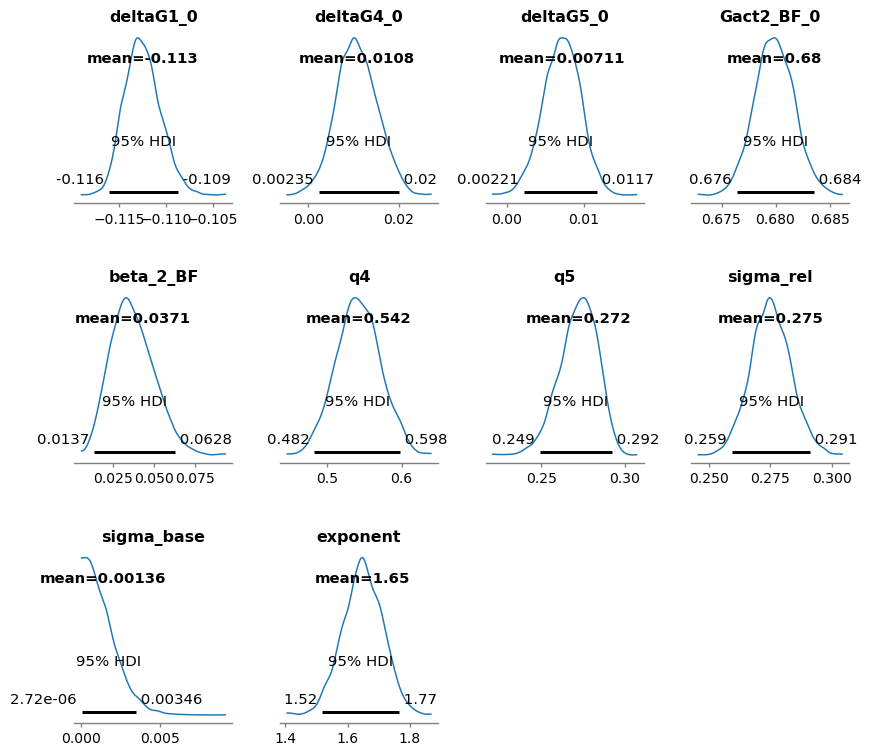

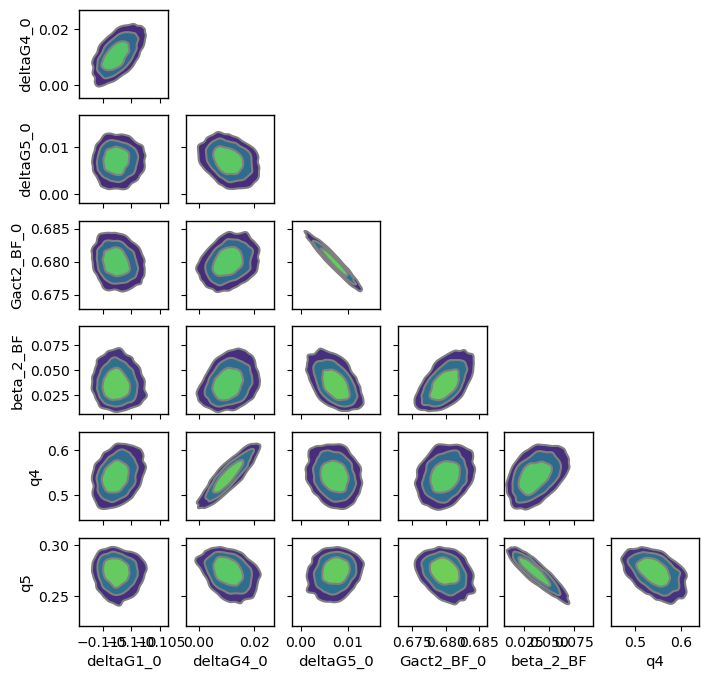

Sampling: [rate]


rate: 0.820


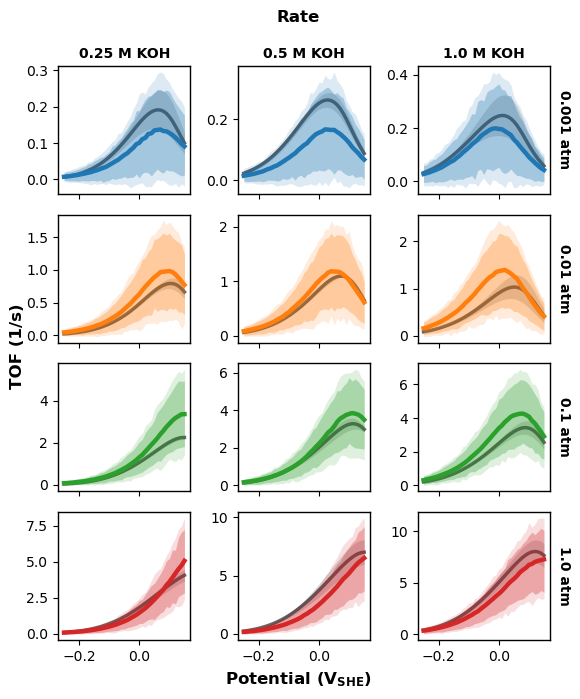

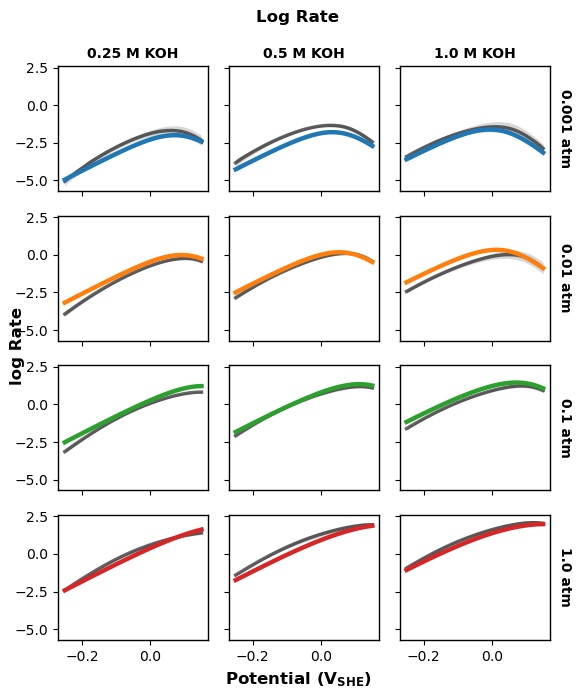

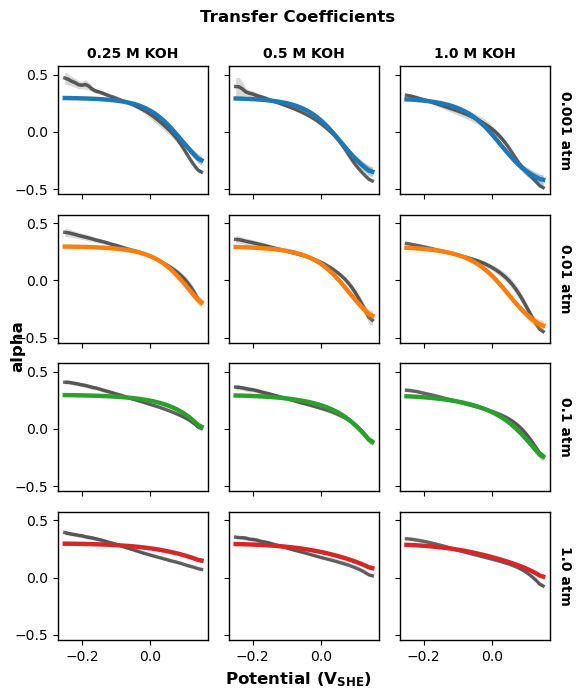

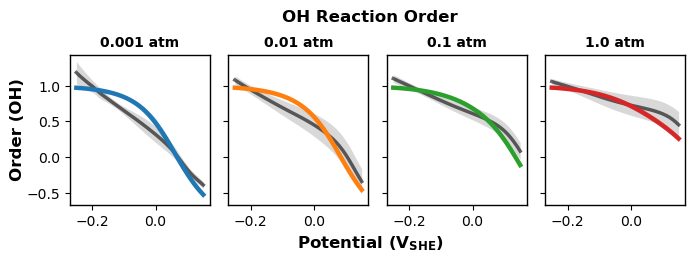

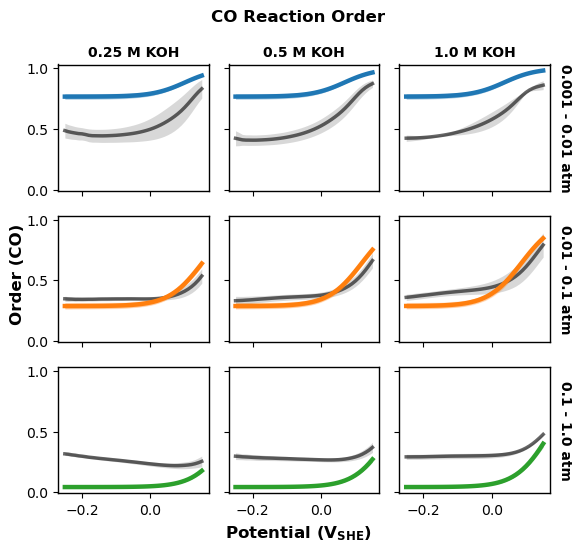

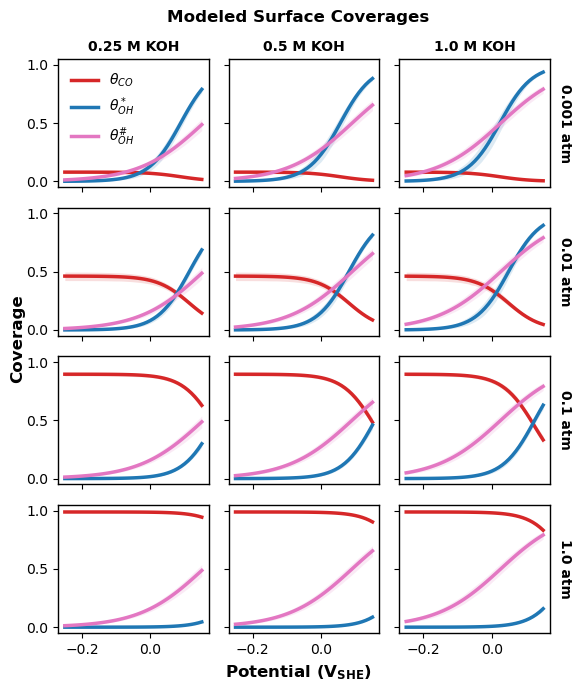

In [31]:
ppc_BF_LH_PCT_Ag_Pd = plot_posteriors(trace_BF_LH_PCT_Ag_Pd, BF_LH_PCT_Ag_Pd)
plot_model_fits(trace_BF_LH_PCT_Ag_Pd, ppc_BF_LH_PCT_Ag_Pd); plot_coverages(trace_BF_LH_PCT_Ag_Pd)

# Comparison

              rank    elpd_loo      p_loo  elpd_diff    weight         se        dse  warning scale
BF_ER_PCT_Ag     0  496.752661  10.590410   0.000000  0.769030  49.933334   0.000000    False   log
BF_PCT_Ag        1  489.401001   9.333413   7.351660  0.132667  49.979172   3.987028    False   log
BF_ER_LH         2  414.039458  12.025160  82.713203  0.098303  50.818389  14.243365    False   log


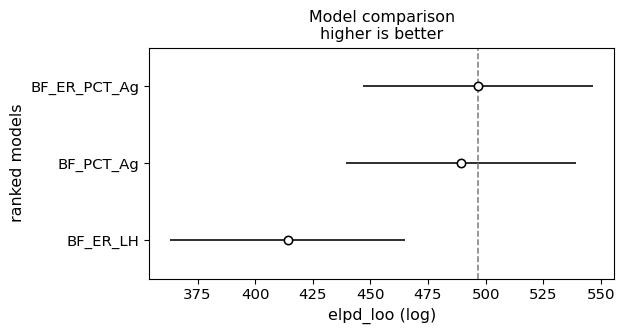

In [34]:
comparison_dict = {
    # "LH": loo_LH, # Low ELPD - bad fits
    # "BF": loo_BF, # Low ELPD - bad fits
    # "ER": loo_ER, # Moderate ELPD
    # "BF_ER": loo_BF_ER, # Should be equivalent to BF_PCT_Ag
    "BF_ER_LH": loo_BF_ER_LH, # Should be equivalent to BF_LH_PCT_Ag, but is not. 
    "BF_PCT_Ag": loo_BF_PCT_Ag, # Good model! 
    # "BF_LH_PCT_Ag": loo_BF_LH_PCT_Ag, # LH DRC too low. 
    "BF_ER_PCT_Ag": loo_BF_ER_PCT_Ag, # ER has low DRCs. 
    # "BF_LH_ER_PCT_Ag": loo_BF_LH_ER_PCT_Ag, # Both LH and ER have low DRCs. 
    # "CO_BF_PCT_Ag": loo_CO_BF_PCT_Ag, # CO adsorption DRC is negligible. 
    # "OH_Ag_BF_PCT_Ag": loo_OH_Ag_BF_PCT_Ag, # High ELPD, but unphysical. Very low CO binding energy. Suggests OH ads on Ag has high DRCs. 
    # "BF_LH_PCT_Ag_Pd": loo_BF_LH_PCT_Ag_Pd # Minimal ELPD increase - LH has low DRCs. 
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()